In [1]:
# =========================
# 0) Setup e imports - Competencia Data Mining UBA 2025
# =========================
!pip -q install polars==1.7.1 sympy matplotlib seaborn google-cloud-storage

import polars as pl
from pathlib import Path
from types import SimpleNamespace
import json, numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import optuna
from sympy import primerange
from google.cloud import storage

# Seeds oficiales de la competencia
SEEDS = [509963, 739373, 794341, 900623, 917827]
# Semillas adicionales (números primos grandes)
SEEDS_EXTRA = [1299827, 1500007, 1700021, 1900009, 2100013]
SEEDS_ALL = SEEDS + SEEDS_EXTRA  # 10 semillas totales

# Paths definitivos en Google Cloud / repo git
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
CSV_PATH    = PROJECT_ROOT / "datasets" / "competencia_02_crudo.csv"
SCHEMA_PATH = NOTEBOOK_DIR / "schema.json"
BASE_DIR    = NOTEBOOK_DIR / "dmeyf2025"

BUCKET_NAME = "nicocaviglia031_bukito3"
BUCKET_LOCAL_DIR = PROJECT_ROOT / BUCKET_NAME
BUCKET_LOCAL_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# =========================
# 1) Lectura de DF con Schema
# =========================

# Cargar schema
with open(SCHEMA_PATH) as f:
    schema_dict = json.load(f)

# Convertir strings a dtypes de Polars
schema = {k: getattr(pl, v) for k, v in schema_dict.items()}

# Lectura estricta (sin inferir tipos)
df = pl.read_csv(CSV_PATH, schema_overrides=schema)
df = df.rechunk()  # Compactar memoria

# drop_cols = ["mprestamos_personales", "cprestamos_personales"]
# df = df.drop(drop_cols)

df.shape

(4717958, 154)

In [3]:
# =========================
# 1.1) Canaritos + Setup de zLGBM
# =========================

def create_canaritos(df: pl.DataFrame, qcanaritos: int = 5) -> pl.DataFrame:
    """
    Añade un número específico de columnas "canarito" (features aleatorias)
    a un DataFrame de Polars.

    Estas nuevas columnas contendrán valores aleatorios uniformes (entre 0 y 1)
    y se colocarán al principio del DataFrame, manteniendo el orden
    original de las demás columnas.

    Args:
        df (pl.DataFrame): El DataFrame de Polars al que se le añadirán
                           las columnas.
        qcanaritos (int): El número de columnas "canarito" que se
                            desea crear (ej: 5).

    Returns:
        pl.DataFrame: Un nuevo DataFrame con las columnas "canarito" añadidas
                      al principio.
    """

    # 1. Guardar los nombres de las columnas originales
    original_cols = df.columns
    num_filas = df.height
    # 2. Generar la lista de nombres para las nuevas columnas "canarito"
    canary_cols = [f"canarito_{i}" for i in range(1, qcanaritos + 1)]

    # 3. Crear las expresiones Polars para generar los números aleatorios
    #    pl.rand_uniform(0, 1) es el equivalente a runif()
    canary_expressions = [pl.lit(np.random.rand(num_filas)).alias(name) for name in canary_cols]

    # 4. Añadir las nuevas columnas y reordenar todo en un solo paso
    #    Usamos .select() para el reordenamiento final
    df = df.with_columns(
        canary_expressions
    ).select(
        canary_cols + original_cols  # Concatena listas para el nuevo orden
    )

    return df

In [4]:
# =========================
# 2) Construcción de clase_ternaria (baseline del profesor)
# =========================

def agregar_clase_ternaria_optimizada(df: pl.DataFrame) -> pl.DataFrame:
    """
    Versión optimizada usando Polars - Baseline del profesor
    """
    return (
        df.lazy()
        .sort(["numero_de_cliente", "foto_mes"])
        .with_columns([
            pl.when(
                pl.col("foto_mes").shift(-1).over("numero_de_cliente").is_null() &
                (pl.col("foto_mes") != pl.col("foto_mes").max())
            ).then(pl.lit("BAJA+1"))
            .when(
                pl.col("foto_mes").shift(-2).over("numero_de_cliente").is_null() &
                (pl.col("foto_mes") <= pl.col("foto_mes").max() - 2)
            ).then(pl.lit("BAJA+2"))
            .otherwise(pl.lit("CONTINUA"))
            .alias("clase_ternaria")
        ])
        .collect()
    )

# Agregar la columna clase_ternaria
df = agregar_clase_ternaria_optimizada(df)

# Tabla de frecuencia de clase_ternaria por foto_mes
tabla_clases = (
    df.pivot(
        values="numero_de_cliente",
        index="foto_mes",
        on="clase_ternaria",
        aggregate_function="len"
    )
    .fill_null(0)
)

print(tabla_clases)

shape: (32, 4)
┌──────────┬──────────┬────────┬────────┐
│ foto_mes ┆ CONTINUA ┆ BAJA+2 ┆ BAJA+1 │
│ ---      ┆ ---      ┆ ---    ┆ ---    │
│ i64      ┆ u32      ┆ u32    ┆ u32    │
╞══════════╪══════════╪════════╪════════╡
│ 201901   ┆ 122918   ┆ 720    ┆ 635    │
│ 201902   ┆ 123985   ┆ 693    ┆ 723    │
│ 201903   ┆ 124535   ┆ 738    ┆ 694    │
│ 201904   ┆ 125293   ┆ 502    ┆ 743    │
│ 201905   ┆ 126016   ┆ 681    ┆ 505    │
│ …        ┆ …        ┆ …      ┆ …      │
│ 202104   ┆ 161340   ┆ 1126   ┆ 952    │
│ 202105   ┆ 161946   ┆ 842    ┆ 1129   │
│ 202106   ┆ 162336   ┆ 1135   ┆ 842    │
│ 202107   ┆ 163459   ┆ 0      ┆ 1137   │
│ 202108   ┆ 164822   ┆ 0      ┆ 0      │
└──────────┴──────────┴────────┴────────┘


Analizando 152 variables numéricas
Meses disponibles: [201901, 201902, 201903, 201904, 201905, 201906, 201907, 201908, 201909, 201910, 201911, 201912, 202001, 202002, 202003, 202004, 202005, 202006, 202007, 202008, 202009, 202010, 202011, 202012, 202101, 202102, 202103, 202104, 202105, 202106, 202107, 202108]

ANÁLISIS DE DESVIACIÓN ESTÁNDAR PROMEDIO POR MES

Desviación estándar promedio global: 74426.0534
Desviación estándar de las desviaciones estándar: 33954.4632
Umbral de anomalía (z-score > 1.5): 125357.7482

MESES ORDENADOS POR DESVIACIÓN ESTÁNDAR PROMEDIO (mayor a menor)
 foto_mes  std_promedio   z_score  es_anomalo
   201904 183123.443327  3.201270        True
   202104 181888.570435  3.164901        True
   202108 132538.739607  1.711489        True
   202105  97342.862438  0.674928       False
   202106  93741.362614  0.568859       False
   202107  92919.829071  0.544664       False
   202103  85783.499940  0.334491       False
   201910  80013.650258  0.164561       False
 

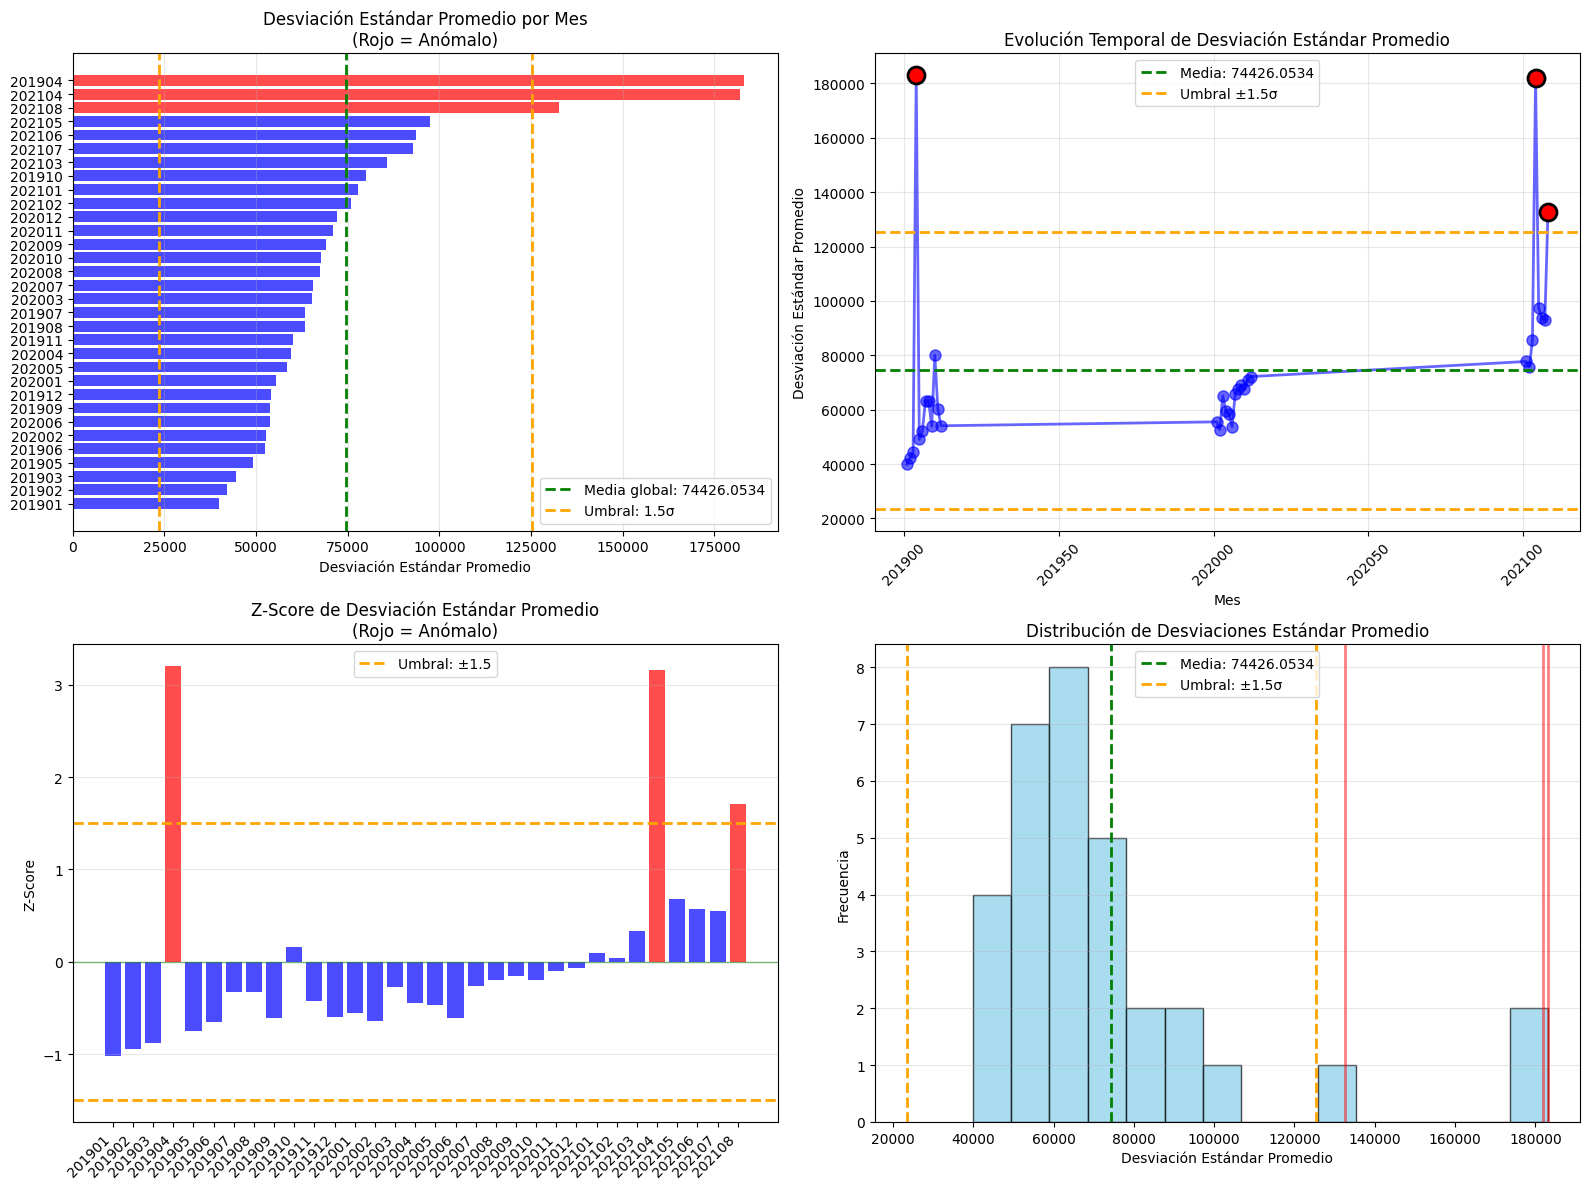

In [5]:
# =========================
# 3.1) Detección de meses anómalos usando desviación estándar promedio
# =========================

# Excluir columnas no numéricas o de metadata
EXCLUDE_ANOMALY = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Obtener columnas numéricas (sin lags aún)
num_cols_base = [c for c, dt in zip(df.columns, df.dtypes)
                 if c not in EXCLUDE_ANOMALY and dt.is_numeric()]

print(f"Analizando {len(num_cols_base)} variables numéricas")
print(f"Meses disponibles: {sorted(df['foto_mes'].unique().to_list())}")

# Calcular desviación estándar por mes para cada variable
std_por_mes = (
    df.lazy()
    .group_by("foto_mes")
    .agg([
        *[pl.col(c).std().alias(f"{c}_std") for c in num_cols_base]
    ])
    .sort("foto_mes")
    .collect()
)

# Convertir a pandas para facilitar cálculos
std_df = std_por_mes.to_pandas()
meses = std_df["foto_mes"].values
std_df = std_df.drop(columns=["foto_mes"])

# Calcular la desviación estándar promedio de todas las variables para cada mes
std_promedio_por_mes = std_df.mean(axis=1)

# Crear DataFrame con resultados
anomaly_results = pd.DataFrame({
    "foto_mes": meses,
    "std_promedio": std_promedio_por_mes.values,
})

# Calcular estadísticas globales para identificar anomalías
media_std_global = std_promedio_por_mes.mean()
std_std_global = std_promedio_por_mes.std()

# Calcular z-score para cada mes (cuántas desviaciones estándar se desvía del promedio)
anomaly_results["z_score"] = (
    (anomaly_results["std_promedio"] - media_std_global) / (std_std_global + 1e-10)
)

# Identificar meses anómalos: aquellos con z-score absoluto > 1.5 (umbral estándar)
umbral_zscore = 1.5
anomaly_results["es_anomalo"] = np.abs(anomaly_results["z_score"]) > umbral_zscore

# Ordenar por desviación estándar promedio (descendente)
anomaly_results = anomaly_results.sort_values("std_promedio", ascending=False)

print("\n" + "="*70)
print("ANÁLISIS DE DESVIACIÓN ESTÁNDAR PROMEDIO POR MES")
print("="*70)
print(f"\nDesviación estándar promedio global: {media_std_global:.4f}")
print(f"Desviación estándar de las desviaciones estándar: {std_std_global:.4f}")
print(f"Umbral de anomalía (z-score > {umbral_zscore}): {media_std_global + umbral_zscore * std_std_global:.4f}")

print("\n" + "="*70)
print("MESES ORDENADOS POR DESVIACIÓN ESTÁNDAR PROMEDIO (mayor a menor)")
print("="*70)
print(anomaly_results[["foto_mes", "std_promedio", "z_score", "es_anomalo"]].to_string(index=False))

# Identificar meses anómalos
meses_anomalos = anomaly_results[anomaly_results["es_anomalo"] == True]["foto_mes"].tolist()

print("\n" + "="*70)
print("MESES ANÓMALOS DETECTADOS")
print("="*70)
if meses_anomalos:
    print(f"\n⚠️  MESES IDENTIFICADOS COMO ANÓMALOS: {meses_anomalos}")
    print(f"\nTotal de meses anómalos: {len(meses_anomalos)}")
    print(f"\nDetalles de meses anómalos:")
    for mes in meses_anomalos:
        row = anomaly_results[anomaly_results["foto_mes"] == mes].iloc[0]
        print(f"\n  📅 Mes {mes}:")
        print(f"     - Desviación estándar promedio: {row['std_promedio']:.4f}")
        print(f"     - Z-score: {row['z_score']:.4f}")
        print(f"     - Desviación respecto al promedio: {row['z_score'] * std_std_global:.4f}")
else:
    print("\n✅ No se detectaron meses anómalos con el umbral establecido.")
    print(f"   (Ningún mes tiene |z-score| > {umbral_zscore})")

print("\n" + "="*70)

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Desviación estándar promedio por mes (barras)
ax1 = axes[0, 0]
colors = ['red' if x else 'blue' for x in anomaly_results["es_anomalo"]]
ax1.barh(range(len(anomaly_results)), anomaly_results["std_promedio"].values, color=colors, alpha=0.7)
ax1.set_yticks(range(len(anomaly_results)))
ax1.set_yticklabels(anomaly_results["foto_mes"].values)
ax1.set_xlabel("Desviación Estándar Promedio")
ax1.set_title("Desviación Estándar Promedio por Mes\n(Rojo = Anómalo)")
ax1.axvline(media_std_global, color='green', linestyle='--', linewidth=2, label=f'Media global: {media_std_global:.4f}')
ax1.axvline(media_std_global + umbral_zscore * std_std_global, color='orange', linestyle='--', linewidth=2, label=f'Umbral: {umbral_zscore}σ')
ax1.axvline(media_std_global - umbral_zscore * std_std_global, color='orange', linestyle='--', linewidth=2)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.legend()

# 2. Desviación estándar promedio por mes (línea temporal)
ax2 = axes[0, 1]
anomaly_sorted = anomaly_results.sort_values("foto_mes")
colors_line = ['red' if x else 'blue' for x in anomaly_sorted["es_anomalo"]]
ax2.plot(anomaly_sorted["foto_mes"], anomaly_sorted["std_promedio"], 
         marker='o', linewidth=2, markersize=8, color='blue', alpha=0.6)
# Marcar puntos anómalos en rojo
for i, (mes, std_val, is_anomalo) in enumerate(zip(anomaly_sorted["foto_mes"], 
                                                     anomaly_sorted["std_promedio"], 
                                                     anomaly_sorted["es_anomalo"])):
    if is_anomalo:
        ax2.scatter(mes, std_val, s=150, c='red', marker='o', zorder=5, edgecolors='black', linewidth=2)
ax2.axhline(media_std_global, color='green', linestyle='--', linewidth=2, label=f'Media: {media_std_global:.4f}')
ax2.axhline(media_std_global + umbral_zscore * std_std_global, color='orange', linestyle='--', linewidth=2, label=f'Umbral ±{umbral_zscore}σ')
ax2.axhline(media_std_global - umbral_zscore * std_std_global, color='orange', linestyle='--', linewidth=2)
ax2.set_xlabel("Mes")
ax2.set_ylabel("Desviación Estándar Promedio")
ax2.set_title("Evolución Temporal de Desviación Estándar Promedio")
ax2.grid(alpha=0.3)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

# 3. Z-score por mes
ax3 = axes[1, 0]
colors_z = ['red' if x else 'blue' for x in anomaly_sorted["es_anomalo"]]
ax3.bar(range(len(anomaly_sorted)), anomaly_sorted["z_score"].values, color=colors_z, alpha=0.7)
ax3.set_xticks(range(len(anomaly_sorted)))
ax3.set_xticklabels(anomaly_sorted["foto_mes"].values, rotation=45, ha='right')
ax3.set_ylabel("Z-Score")
ax3.set_title("Z-Score de Desviación Estándar Promedio\n(Rojo = Anómalo)")
ax3.axhline(umbral_zscore, color='orange', linestyle='--', linewidth=2, label=f'Umbral: ±{umbral_zscore}')
ax3.axhline(-umbral_zscore, color='orange', linestyle='--', linewidth=2)
ax3.axhline(0, color='green', linestyle='-', linewidth=1, alpha=0.5)
ax3.grid(axis='y', alpha=0.3)
ax3.legend()

# 4. Distribución de desviaciones estándar promedio
ax4 = axes[1, 1]
ax4.hist(anomaly_results["std_promedio"], bins=15, edgecolor='black', alpha=0.7, color='skyblue')
ax4.axvline(media_std_global, color='green', linestyle='--', linewidth=2, label=f'Media: {media_std_global:.4f}')
ax4.axvline(media_std_global + umbral_zscore * std_std_global, color='orange', linestyle='--', linewidth=2, label=f'Umbral: ±{umbral_zscore}σ')
ax4.axvline(media_std_global - umbral_zscore * std_std_global, color='orange', linestyle='--', linewidth=2)
# Marcar meses anómalos
for mes_anomalo in meses_anomalos:
    std_val = anomaly_results[anomaly_results["foto_mes"] == mes_anomalo]["std_promedio"].iloc[0]
    ax4.axvline(std_val, color='red', linestyle='-', linewidth=2, alpha=0.5)
ax4.set_xlabel("Desviación Estándar Promedio")
ax4.set_ylabel("Frecuencia")
ax4.set_title("Distribución de Desviaciones Estándar Promedio")
ax4.grid(axis='y', alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()


ANÁLISIS DETALLADO DEL MES 201904

📊 RESUMEN DEL MES 201904
   - Desviación estándar promedio: 183123.4433
   - Desviación estándar promedio de otros meses: 70822.9804
   - Diferencia: 112300.4629

TOP 20 VARIABLES CON MAYOR Z-SCORE (más anómalas en 201904)
                          variable  std_mes_201904  std_promedio_otros_meses  porcentaje_desviacion    z_score
 ctarjeta_visa_debitos_automaticos    0.000000e+00              3.184244e+00            -100.000000 -13.849465
         Visa_mfinanciacion_limite    8.887822e+06              7.584180e+05            1071.889586   7.690117
       Master_mfinanciacion_limite    1.193657e+07              1.008781e+06            1083.266764   4.744709
mttarjeta_visa_debitos_automaticos    0.000000e+00              1.058639e+04            -100.000000  -4.652854
        chomebanking_transacciones    2.268248e+02              6.706555e+01             238.213557   4.037494
                  cpagodeservicios    1.769242e+00              5.919859e-01

/tmp/ipykernel_7458/522122868.py:240: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(data_boxplot, labels=labels_boxplot, vert=True, patch_artist=True)


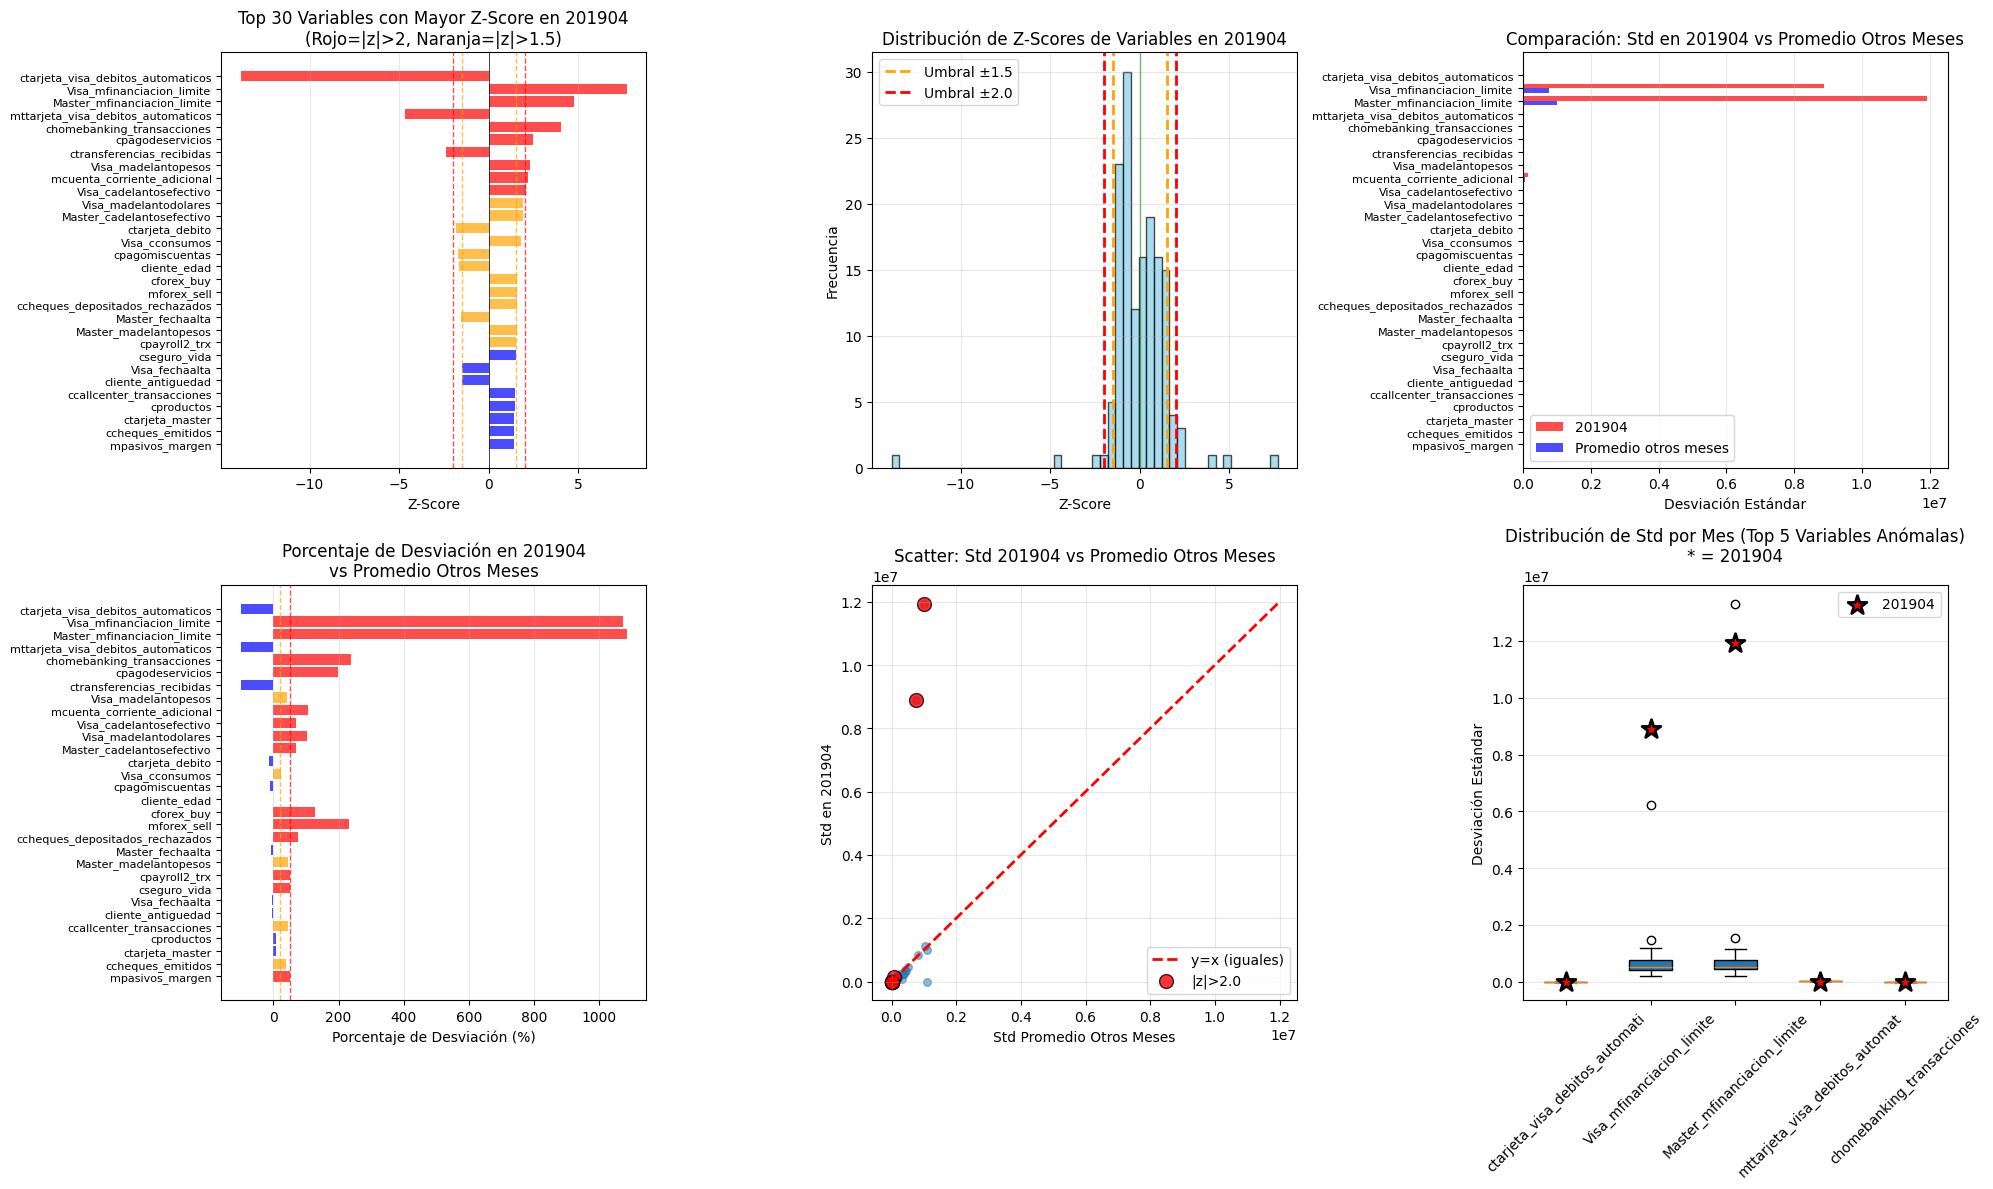


RESUMEN FINAL

✅ Total de variables analizadas: 152
⚠️  Variables con |z-score| > 2.0: 10 (6.6%)
📈 Variables con |z-score| > 1.5: 22 (14.5%)

💡 El mes 201904 tiene alta variabilidad principalmente en:
   - Visa: z-score promedio = 1.76



In [6]:
# =========================
# 3.1.1) Análisis detallado del mes 201904 - ¿Qué causa la alta variabilidad?
# =========================

mes_analizar = 201904

print("="*80)
print(f"ANÁLISIS DETALLADO DEL MES {mes_analizar}")
print("="*80)

# Excluir columnas no numéricas o de metadata
EXCLUDE_ANOMALY = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Obtener columnas numéricas (sin lags aún)
num_cols_base = [c for c, dt in zip(df.columns, df.dtypes)
                 if c not in EXCLUDE_ANOMALY and dt.is_numeric()]

# Calcular desviación estándar por mes para cada variable
std_por_mes_detalle = (
    df.lazy()
    .group_by("foto_mes")
    .agg([
        *[pl.col(c).std().alias(f"{c}_std") for c in num_cols_base]
    ])
    .sort("foto_mes")
    .collect()
)

# Convertir a pandas
std_df_detalle = std_por_mes_detalle.to_pandas()
meses_detalle = std_df_detalle["foto_mes"].values

# Obtener desviación estándar del mes a analizar
if mes_analizar not in meses_detalle:
    print(f"\n❌ El mes {mes_analizar} no está en el dataset.")
else:
    # Filtrar datos del mes a analizar
    std_mes_analizar = std_df_detalle[std_df_detalle["foto_mes"] == mes_analizar].iloc[0]
    
    # Calcular desviación estándar promedio de todos los meses (excluyendo el mes anómalo)
    meses_normales = [m for m in meses_detalle if m != mes_analizar]
    std_df_normales = std_df_detalle[std_df_detalle["foto_mes"].isin(meses_normales)]
    
    # Calcular media y std de desviaciones estándar para cada variable
    std_media_por_variable = std_df_normales.drop(columns=["foto_mes"]).mean()
    std_std_por_variable = std_df_normales.drop(columns=["foto_mes"]).std()
    
    # Crear DataFrame con análisis detallado
    analisis_detalle = []
    for col in num_cols_base:
        col_std = f"{col}_std"
        std_val_mes = std_mes_analizar[col_std]
        std_media_global = std_media_por_variable[col_std]
        std_std_global = std_std_por_variable[col_std]
        
        if std_std_global > 0:
            z_score_var = (std_val_mes - std_media_global) / std_std_global
            desviacion_abs = std_val_mes - std_media_global
            porcentaje_desviacion = (desviacion_abs / (std_media_global + 1e-10)) * 100
        else:
            z_score_var = 0
            desviacion_abs = std_val_mes - std_media_global
            porcentaje_desviacion = 0
        
        analisis_detalle.append({
            "variable": col,
            "std_mes_201904": std_val_mes,
            "std_promedio_otros_meses": std_media_global,
            "desviacion_absoluta": desviacion_abs,
            "porcentaje_desviacion": porcentaje_desviacion,
            "z_score": z_score_var
        })
    
    df_analisis = pd.DataFrame(analisis_detalle)
    
    # Ordenar por z-score absoluto (las más anómalas primero)
    df_analisis["z_score_abs"] = df_analisis["z_score"].abs()
    df_analisis = df_analisis.sort_values("z_score_abs", ascending=False)
    
    print(f"\n📊 RESUMEN DEL MES {mes_analizar}")
    print(f"   - Desviación estándar promedio: {df_analisis['std_mes_201904'].mean():.4f}")
    print(f"   - Desviación estándar promedio de otros meses: {df_analisis['std_promedio_otros_meses'].mean():.4f}")
    print(f"   - Diferencia: {df_analisis['std_mes_201904'].mean() - df_analisis['std_promedio_otros_meses'].mean():.4f}")
    
    # Top 20 variables más problemáticas
    print("\n" + "="*80)
    print("TOP 20 VARIABLES CON MAYOR Z-SCORE (más anómalas en 201904)")
    print("="*80)
    top_20 = df_analisis.head(20)
    print(top_20[["variable", "std_mes_201904", "std_promedio_otros_meses", 
                  "porcentaje_desviacion", "z_score"]].to_string(index=False))
    
    # Variables con z-score > 2 (muy anómalas)
    vars_muy_anomalas = df_analisis[df_analisis["z_score_abs"] > 2.0]
    print(f"\n⚠️  Variables con |z-score| > 2.0: {len(vars_muy_anomalas)}")
    if len(vars_muy_anomalas) > 0:
        print("\nVariables muy anómalas:")
        for idx, row in vars_muy_anomalas.head(10).iterrows():
            print(f"   - {row['variable']}: z-score={row['z_score']:.2f}, "
                  f"desviación={row['porcentaje_desviacion']:.1f}%")
    
    # Variables con z-score > 1.5 (anómalas)
    vars_anomalas = df_analisis[df_analisis["z_score_abs"] > 1.5]
    print(f"\n📈 Variables con |z-score| > 1.5: {len(vars_anomalas)}")
    
    # Estadísticas por categoría de variables
    print("\n" + "="*80)
    print("ANÁLISIS POR CATEGORÍAS DE VARIABLES")
    print("="*80)
    
    # Identificar categorías comunes
    categorias = {
        "Montos (m_)": [c for c in num_cols_base if c.startswith("m_")],
        "Contadores (c_)": [c for c in num_cols_base if c.startswith("c") and not c.startswith("m_")],
        "Visa": [c for c in num_cols_base if "Visa" in c or "visa" in c],
        "Master": [c for c in num_cols_base if "Master" in c or "master" in c],
        "Payroll": [c for c in num_cols_base if "payroll" in c.lower()],
        "Prestamos": [c for c in num_cols_base if "prestamo" in c.lower()],
        "Inversiones": [c for c in num_cols_base if "inversion" in c.lower() or "plazo_fijo" in c.lower()],
    }
    
    for cat_name, vars_cat in categorias.items():
        if len(vars_cat) > 0:
            df_cat = df_analisis[df_analisis["variable"].isin(vars_cat)]
            if len(df_cat) > 0:
                z_score_promedio = df_cat["z_score_abs"].mean()
                vars_anomalas_cat = len(df_cat[df_cat["z_score_abs"] > 1.5])
                print(f"\n{cat_name}:")
                print(f"   - Variables en categoría: {len(df_cat)}")
                print(f"   - Z-score promedio (abs): {z_score_promedio:.2f}")
                print(f"   - Variables anómalas (|z|>1.5): {vars_anomalas_cat}")
                if vars_anomalas_cat > 0:
                    top_cat = df_cat.nlargest(3, "z_score_abs")
                    print(f"   - Top 3 más anómalas:")
                    for _, row in top_cat.iterrows():
                        print(f"     * {row['variable']}: z={row['z_score']:.2f}")
    
    # Visualizaciones
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # 1. Top 30 variables con mayor z-score
    ax1 = axes[0, 0]
    top_30 = df_analisis.head(30)
    colors = ['red' if abs(z) > 2 else 'orange' if abs(z) > 1.5 else 'blue' 
              for z in top_30["z_score"]]
    ax1.barh(range(len(top_30)), top_30["z_score"].values, color=colors, alpha=0.7)
    ax1.set_yticks(range(len(top_30)))
    ax1.set_yticklabels(top_30["variable"].values, fontsize=8)
    ax1.set_xlabel("Z-Score")
    ax1.set_title(f"Top 30 Variables con Mayor Z-Score en {mes_analizar}\n(Rojo=|z|>2, Naranja=|z|>1.5)")
    ax1.axvline(1.5, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax1.axvline(-1.5, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax1.axvline(2.0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax1.axvline(-2.0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax1.axvline(0, color='black', linestyle='-', linewidth=0.5)
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # 2. Distribución de z-scores
    ax2 = axes[0, 1]
    ax2.hist(df_analisis["z_score"], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    ax2.axvline(1.5, color='orange', linestyle='--', linewidth=2, label='Umbral ±1.5')
    ax2.axvline(-1.5, color='orange', linestyle='--', linewidth=2)
    ax2.axvline(2.0, color='red', linestyle='--', linewidth=2, label='Umbral ±2.0')
    ax2.axvline(-2.0, color='red', linestyle='--', linewidth=2)
    ax2.axvline(0, color='green', linestyle='-', linewidth=1, alpha=0.5)
    ax2.set_xlabel("Z-Score")
    ax2.set_ylabel("Frecuencia")
    ax2.set_title(f"Distribución de Z-Scores de Variables en {mes_analizar}")
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # 3. Comparación: std en 201904 vs promedio otros meses (top 30)
    ax3 = axes[0, 2]
    top_30_comp = df_analisis.head(30)
    x_pos = np.arange(len(top_30_comp))
    width = 0.35
    ax3.barh(x_pos - width/2, top_30_comp["std_mes_201904"].values, width, 
             label=f'201904', color='red', alpha=0.7)
    ax3.barh(x_pos + width/2, top_30_comp["std_promedio_otros_meses"].values, width, 
             label='Promedio otros meses', color='blue', alpha=0.7)
    ax3.set_yticks(x_pos)
    ax3.set_yticklabels(top_30_comp["variable"].values, fontsize=8)
    ax3.set_xlabel("Desviación Estándar")
    ax3.set_title(f"Comparación: Std en {mes_analizar} vs Promedio Otros Meses")
    ax3.legend()
    ax3.invert_yaxis()
    ax3.grid(axis='x', alpha=0.3)
    
    # 4. Porcentaje de desviación (top 30)
    ax4 = axes[1, 0]
    top_30_pct = df_analisis.head(30)
    colors_pct = ['red' if p > 50 else 'orange' if p > 20 else 'blue' 
                  for p in top_30_pct["porcentaje_desviacion"]]
    ax4.barh(range(len(top_30_pct)), top_30_pct["porcentaje_desviacion"].values, 
             color=colors_pct, alpha=0.7)
    ax4.set_yticks(range(len(top_30_pct)))
    ax4.set_yticklabels(top_30_pct["variable"].values, fontsize=8)
    ax4.set_xlabel("Porcentaje de Desviación (%)")
    ax4.set_title(f"Porcentaje de Desviación en {mes_analizar}\nvs Promedio Otros Meses")
    ax4.axvline(20, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax4.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax4.invert_yaxis()
    ax4.grid(axis='x', alpha=0.3)
    
    # 5. Scatter: std 201904 vs std promedio otros meses
    ax5 = axes[1, 1]
    ax5.scatter(df_analisis["std_promedio_otros_meses"], 
                df_analisis["std_mes_201904"], 
                alpha=0.5, s=30)
    # Línea y=x (donde estarían si fueran iguales)
    max_val = max(df_analisis["std_promedio_otros_meses"].max(), 
                  df_analisis["std_mes_201904"].max())
    ax5.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='y=x (iguales)')
    # Marcar las más anómalas
    vars_extremas = df_analisis[df_analisis["z_score_abs"] > 2.0]
    if len(vars_extremas) > 0:
        ax5.scatter(vars_extremas["std_promedio_otros_meses"], 
                   vars_extremas["std_mes_201904"], 
                   color='red', s=100, alpha=0.8, label='|z|>2.0', edgecolors='black')
    ax5.set_xlabel("Std Promedio Otros Meses")
    ax5.set_ylabel(f"Std en {mes_analizar}")
    ax5.set_title(f"Scatter: Std {mes_analizar} vs Promedio Otros Meses")
    ax5.legend()
    ax5.grid(alpha=0.3)
    
    # 6. Boxplot de desviaciones estándar por mes (solo algunas variables clave)
    ax6 = axes[1, 2]
    # Seleccionar las 5 variables más anómalas
    top_5_vars = df_analisis.head(5)["variable"].tolist()
    # Preparar datos para boxplot
    data_boxplot = []
    labels_boxplot = []
    for var in top_5_vars:
        col_std = f"{var}_std"
        valores = std_df_detalle[col_std].values
        data_boxplot.append(valores)
        labels_boxplot.append(var[:30])  # Truncar nombres largos
    
    bp = ax6.boxplot(data_boxplot, labels=labels_boxplot, vert=True, patch_artist=True)
    # Colorear el box del mes 201904
    for i, var in enumerate(top_5_vars):
        col_std = f"{var}_std"
        std_val_201904 = std_mes_analizar[col_std]
        # Marcar el valor de 201904
        ax6.scatter([i+1], [std_val_201904], s=200, c='red', marker='*', 
                   zorder=10, edgecolors='black', linewidth=2, label='201904' if i == 0 else '')
    
    ax6.set_ylabel("Desviación Estándar")
    ax6.set_title("Distribución de Std por Mes (Top 5 Variables Anómalas)\n* = 201904")
    ax6.tick_params(axis='x', rotation=45)
    ax6.grid(axis='y', alpha=0.3)
    ax6.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Resumen final
    print("\n" + "="*80)
    print("RESUMEN FINAL")
    print("="*80)
    print(f"\n✅ Total de variables analizadas: {len(df_analisis)}")
    print(f"⚠️  Variables con |z-score| > 2.0: {len(vars_muy_anomalas)} ({len(vars_muy_anomalas)/len(df_analisis)*100:.1f}%)")
    print(f"📈 Variables con |z-score| > 1.5: {len(vars_anomalas)} ({len(vars_anomalas)/len(df_analisis)*100:.1f}%)")
    print(f"\n💡 El mes {mes_analizar} tiene alta variabilidad principalmente en:")
    if len(vars_muy_anomalas) > 0:
        top_categorias = []
        for cat_name, vars_cat in categorias.items():
            df_cat = df_analisis[df_analisis["variable"].isin(vars_cat)]
            if len(df_cat) > 0:
                z_prom = df_cat["z_score_abs"].mean()
                if z_prom > 1.5:
                    top_categorias.append((cat_name, z_prom))
        top_categorias.sort(key=lambda x: x[1], reverse=True)
        for cat, z_prom in top_categorias[:5]:
            print(f"   - {cat}: z-score promedio = {z_prom:.2f}")
    
    print("\n" + "="*80)


Analizando 152 variables numéricas con PSI
Meses disponibles: [201901, 201902, 201903, 201904, 201905, 201906, 201907, 201908, 201909, 201910, 201911, 201912, 202001, 202002, 202003, 202004, 202005, 202006, 202007, 202008, 202009, 202010, 202011, 202012, 202101, 202102, 202103, 202104, 202105, 202106, 202107, 202108]

Mes de referencia para PSI: 202005

ANÁLISIS DE PSI (Population Stability Index) POR MES

Mes de referencia: 202005
Umbral PSI para cambio moderado: 0.1
Umbral PSI para cambio significativo (anómalo): 0.25

MESES ORDENADOS POR PSI PROMEDIO (mayor a menor)
 foto_mes  psi_promedio  psi_maximo  variables_alto_psi categoria_psi  es_anomalo_psi
   202006      0.973330   30.127862                  16       Anómalo            True
   202010      0.303631   20.655078                   6       Anómalo            True
   202106      0.209330   11.500459                   5      Moderado           False
   202007      0.192249   21.805128                   2      Moderado           

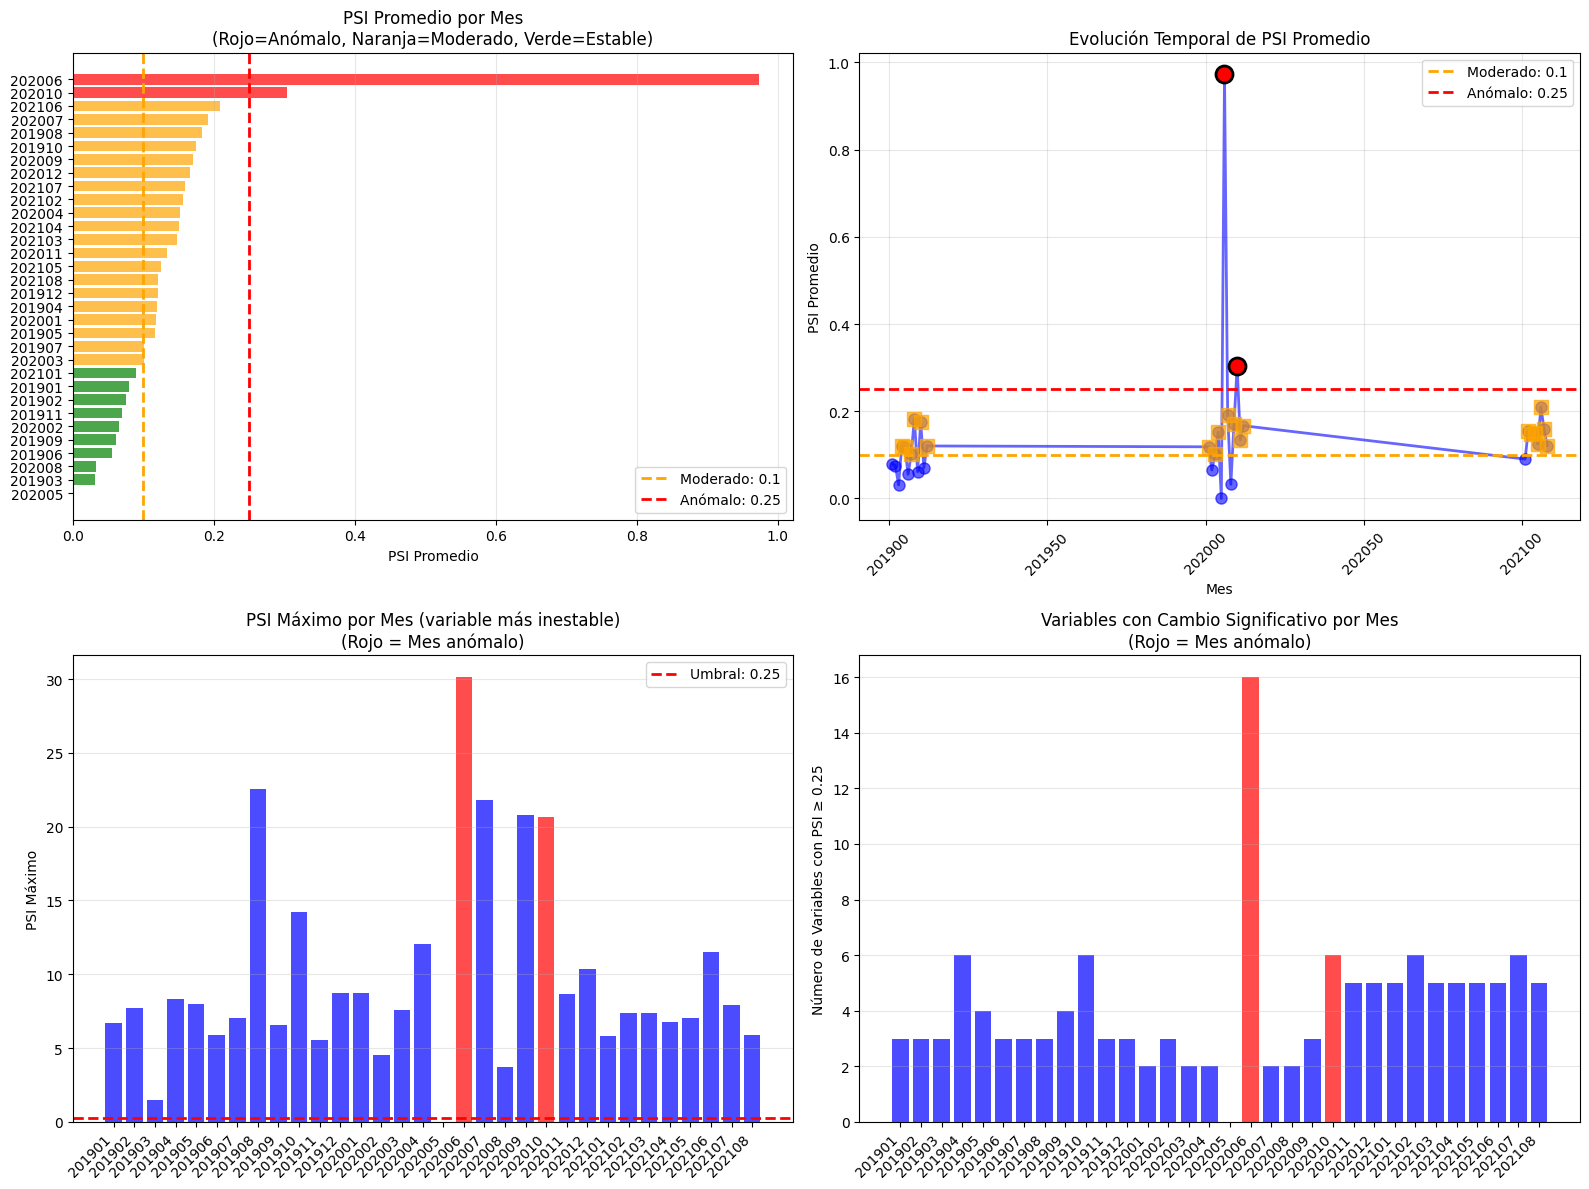

In [7]:
# =========================
# 3.2) Detección de meses anómalos usando PSI (Population Stability Index)
# =========================

def calculate_psi(expected, actual, bins=10):
    """
    Calcula el Population Stability Index (PSI) entre dos distribuciones.
    
    PSI mide la estabilidad de la distribución de una variable:
    - PSI < 0.1: Sin cambio significativo
    - 0.1 ≤ PSI < 0.25: Cambio moderado
    - PSI ≥ 0.25: Cambio significativo
    
    Args:
        expected: Distribución esperada (mes de referencia)
        actual: Distribución actual (mes a comparar)
        bins: Número de bins para discretizar
    
    Returns:
        PSI value
    """
    # Filtrar valores no nulos
    expected = expected[~np.isnan(expected)]
    actual = actual[~np.isnan(actual)]
    
    if len(expected) == 0 or len(actual) == 0:
        return np.nan
    
    # Crear bins basados en la distribución esperada
    min_val = min(expected.min(), actual.min())
    max_val = max(expected.max(), actual.max())
    
    # Evitar división por cero
    if max_val == min_val:
        return 0.0
    
    # Crear bins
    bin_edges = np.linspace(min_val, max_val, bins + 1)
    
    # Calcular frecuencias
    expected_counts, _ = np.histogram(expected, bins=bin_edges)
    actual_counts, _ = np.histogram(actual, bins=bin_edges)
    
    # Normalizar a proporciones
    expected_prop = expected_counts / (len(expected) + 1e-10)
    actual_prop = actual_counts / (len(actual) + 1e-10)
    
    # Evitar log(0)
    expected_prop = np.where(expected_prop == 0, 1e-10, expected_prop)
    actual_prop = np.where(actual_prop == 0, 1e-10, actual_prop)
    
    # Calcular PSI
    psi = np.sum((actual_prop - expected_prop) * np.log(actual_prop / expected_prop))
    
    return psi

# Excluir columnas no numéricas o de metadata
EXCLUDE_ANOMALY = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Obtener columnas numéricas (sin lags aún)
num_cols_base = [c for c, dt in zip(df.columns, df.dtypes)
                 if c not in EXCLUDE_ANOMALY and dt.is_numeric()]

print(f"Analizando {len(num_cols_base)} variables numéricas con PSI")
print(f"Meses disponibles: {sorted(df['foto_mes'].unique().to_list())}")

# Convertir a pandas para facilitar cálculos de PSI
df_pd = df.select(["foto_mes"] + num_cols_base).to_pandas()
meses = sorted(df_pd["foto_mes"].unique())

# Elegir mes de referencia: usar la mediana de todos los meses (mes del medio)
mes_referencia = meses[len(meses) // 2]
print(f"\nMes de referencia para PSI: {mes_referencia}")

# Obtener datos del mes de referencia
df_referencia = df_pd[df_pd["foto_mes"] == mes_referencia]

# Calcular PSI para cada variable y cada mes
psi_results = []

for mes in meses:
    if mes == mes_referencia:
        # El mes de referencia tiene PSI = 0
        psi_results.append({
            "foto_mes": mes,
            "psi_promedio": 0.0,
            "psi_maximo": 0.0,
            "variables_alto_psi": 0
        })
        continue
    
    df_mes = df_pd[df_pd["foto_mes"] == mes]
    psi_por_variable = []
    
    for col in num_cols_base:
        try:
            psi_val = calculate_psi(
                df_referencia[col].values,
                df_mes[col].values,
                bins=10
            )
            if not np.isnan(psi_val):
                psi_por_variable.append(psi_val)
        except Exception as e:
            # Si hay error, omitir esta variable
            continue
    
    if len(psi_por_variable) > 0:
        psi_promedio = np.mean(psi_por_variable)
        psi_maximo = np.max(psi_por_variable)
        # Contar variables con PSI >= 0.25 (cambio significativo)
        variables_alto_psi = sum(1 for p in psi_por_variable if p >= 0.25)
    else:
        psi_promedio = np.nan
        psi_maximo = np.nan
        variables_alto_psi = 0
    
    psi_results.append({
        "foto_mes": mes,
        "psi_promedio": psi_promedio,
        "psi_maximo": psi_maximo,
        "variables_alto_psi": variables_alto_psi
    })

# Crear DataFrame con resultados
psi_df = pd.DataFrame(psi_results)

# Identificar meses anómalos basado en PSI
# Umbrales de PSI:
# - PSI < 0.1: Sin cambio significativo
# - 0.1 ≤ PSI < 0.25: Cambio moderado
# - PSI ≥ 0.25: Cambio significativo (anómalo)
umbral_psi_anomalo = 0.25
umbral_psi_moderado = 0.1

psi_df["categoria_psi"] = pd.cut(
    psi_df["psi_promedio"],
    bins=[-np.inf, umbral_psi_moderado, umbral_psi_anomalo, np.inf],
    labels=["Estable", "Moderado", "Anómalo"]
)

psi_df["es_anomalo_psi"] = psi_df["psi_promedio"] >= umbral_psi_anomalo

# Ordenar por PSI promedio (descendente)
psi_df = psi_df.sort_values("psi_promedio", ascending=False)

print("\n" + "="*70)
print("ANÁLISIS DE PSI (Population Stability Index) POR MES")
print("="*70)
print(f"\nMes de referencia: {mes_referencia}")
print(f"Umbral PSI para cambio moderado: {umbral_psi_moderado}")
print(f"Umbral PSI para cambio significativo (anómalo): {umbral_psi_anomalo}")

print("\n" + "="*70)
print("MESES ORDENADOS POR PSI PROMEDIO (mayor a menor)")
print("="*70)
print(psi_df[["foto_mes", "psi_promedio", "psi_maximo", "variables_alto_psi", "categoria_psi", "es_anomalo_psi"]].to_string(index=False))

# Identificar meses anómalos
meses_anomalos_psi = psi_df[psi_df["es_anomalo_psi"] == True]["foto_mes"].tolist()

print("\n" + "="*70)
print("MESES ANÓMALOS DETECTADOS POR PSI")
print("="*70)
if meses_anomalos_psi:
    print(f"\n⚠️  MESES IDENTIFICADOS COMO ANÓMALOS (PSI ≥ {umbral_psi_anomalo}): {meses_anomalos_psi}")
    print(f"\nTotal de meses anómalos: {len(meses_anomalos_psi)}")
    print(f"\nDetalles de meses anómalos:")
    for mes in meses_anomalos_psi:
        row = psi_df[psi_df["foto_mes"] == mes].iloc[0]
        print(f"\n  📅 Mes {mes}:")
        print(f"     - PSI promedio: {row['psi_promedio']:.4f}")
        print(f"     - PSI máximo: {row['psi_maximo']:.4f}")
        print(f"     - Variables con PSI ≥ 0.25: {row['variables_alto_psi']}")
        print(f"     - Categoría: {row['categoria_psi']}")
else:
    print(f"\n✅ No se detectaron meses anómalos con PSI ≥ {umbral_psi_anomalo}.")
    print("   Todos los meses tienen cambios moderados o estables respecto al mes de referencia.")

# Meses con cambios moderados
meses_moderados = psi_df[
    (psi_df["psi_promedio"] >= umbral_psi_moderado) & 
    (psi_df["psi_promedio"] < umbral_psi_anomalo)
]["foto_mes"].tolist()

if meses_moderados:
    print(f"\n📊 Meses con cambios moderados (0.1 ≤ PSI < 0.25): {meses_moderados}")

print("\n" + "="*70)

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. PSI promedio por mes (barras)
ax1 = axes[0, 0]
colors = ['red' if x else 'orange' if 0.1 <= y < 0.25 else 'green' 
          for x, y in zip(psi_df["es_anomalo_psi"], psi_df["psi_promedio"])]
ax1.barh(range(len(psi_df)), psi_df["psi_promedio"].values, color=colors, alpha=0.7)
ax1.set_yticks(range(len(psi_df)))
ax1.set_yticklabels(psi_df["foto_mes"].values)
ax1.set_xlabel("PSI Promedio")
ax1.set_title("PSI Promedio por Mes\n(Rojo=Anómalo, Naranja=Moderado, Verde=Estable)")
ax1.axvline(umbral_psi_moderado, color='orange', linestyle='--', linewidth=2, label=f'Moderado: {umbral_psi_moderado}')
ax1.axvline(umbral_psi_anomalo, color='red', linestyle='--', linewidth=2, label=f'Anómalo: {umbral_psi_anomalo}')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.legend()

# 2. PSI promedio por mes (línea temporal)
ax2 = axes[0, 1]
psi_sorted = psi_df.sort_values("foto_mes")
colors_line = ['red' if x else 'orange' if 0.1 <= y < 0.25 else 'blue'
               for x, y in zip(psi_sorted["es_anomalo_psi"], psi_sorted["psi_promedio"])]
ax2.plot(psi_sorted["foto_mes"], psi_sorted["psi_promedio"], 
         marker='o', linewidth=2, markersize=8, color='blue', alpha=0.6)
# Marcar puntos anómalos en rojo
for i, (mes, psi_val, is_anomalo) in enumerate(zip(psi_sorted["foto_mes"], 
                                                     psi_sorted["psi_promedio"], 
                                                     psi_sorted["es_anomalo_psi"])):
    if is_anomalo:
        ax2.scatter(mes, psi_val, s=150, c='red', marker='o', zorder=5, edgecolors='black', linewidth=2)
    elif 0.1 <= psi_val < 0.25:
        ax2.scatter(mes, psi_val, s=100, c='orange', marker='s', zorder=5, alpha=0.7)
ax2.axhline(umbral_psi_moderado, color='orange', linestyle='--', linewidth=2, label=f'Moderado: {umbral_psi_moderado}')
ax2.axhline(umbral_psi_anomalo, color='red', linestyle='--', linewidth=2, label=f'Anómalo: {umbral_psi_anomalo}')
ax2.set_xlabel("Mes")
ax2.set_ylabel("PSI Promedio")
ax2.set_title("Evolución Temporal de PSI Promedio")
ax2.grid(alpha=0.3)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

# 3. PSI máximo por mes
ax3 = axes[1, 0]
colors_max = ['red' if x else 'blue' for x in psi_sorted["es_anomalo_psi"]]
ax3.bar(range(len(psi_sorted)), psi_sorted["psi_maximo"].values, color=colors_max, alpha=0.7)
ax3.set_xticks(range(len(psi_sorted)))
ax3.set_xticklabels(psi_sorted["foto_mes"].values, rotation=45, ha='right')
ax3.set_ylabel("PSI Máximo")
ax3.set_title("PSI Máximo por Mes (variable más inestable)\n(Rojo = Mes anómalo)")
ax3.axhline(umbral_psi_anomalo, color='red', linestyle='--', linewidth=2, label=f'Umbral: {umbral_psi_anomalo}')
ax3.grid(axis='y', alpha=0.3)
ax3.legend()

# 4. Número de variables con PSI alto por mes
ax4 = axes[1, 1]
colors_vars = ['red' if x else 'blue' for x in psi_sorted["es_anomalo_psi"]]
ax4.bar(range(len(psi_sorted)), psi_sorted["variables_alto_psi"].values, color=colors_vars, alpha=0.7)
ax4.set_xticks(range(len(psi_sorted)))
ax4.set_xticklabels(psi_sorted["foto_mes"].values, rotation=45, ha='right')
ax4.set_ylabel("Número de Variables con PSI ≥ 0.25")
ax4.set_title("Variables con Cambio Significativo por Mes\n(Rojo = Mes anómalo)")
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


ANÁLISIS DETALLADO DE MESES: [201904, 202006, 202010]

ANÁLISIS DEL MES 201904

📊 RESUMEN DEL MES 201904
   - Desviación estándar promedio: 183123.4433
   - Desviación estándar promedio de otros meses: 71519.2611
   - Diferencia: 111604.1822

TOP 20 VARIABLES CON MAYOR Z-SCORE (más anómalas en 201904)
                          variable  std_mes_201904  std_promedio_otros_meses  porcentaje_desviacion    z_score
 ctarjeta_visa_debitos_automaticos    0.000000e+00              3.193490e+00            -100.000000 -13.606344
         Visa_mfinanciacion_limite    8.887822e+06              7.759435e+05            1045.421180   7.428723
       Master_mfinanciacion_limite    1.193657e+07              1.038428e+06            1049.484784   4.577303
mttarjeta_visa_debitos_automaticos    0.000000e+00              1.057935e+04            -100.000000  -4.494464
        chomebanking_transacciones    2.268248e+02              6.891584e+01             229.133032   4.067801
                  cpagodeservic

/tmp/ipykernel_7458/889053266.py:295: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax6.boxplot(


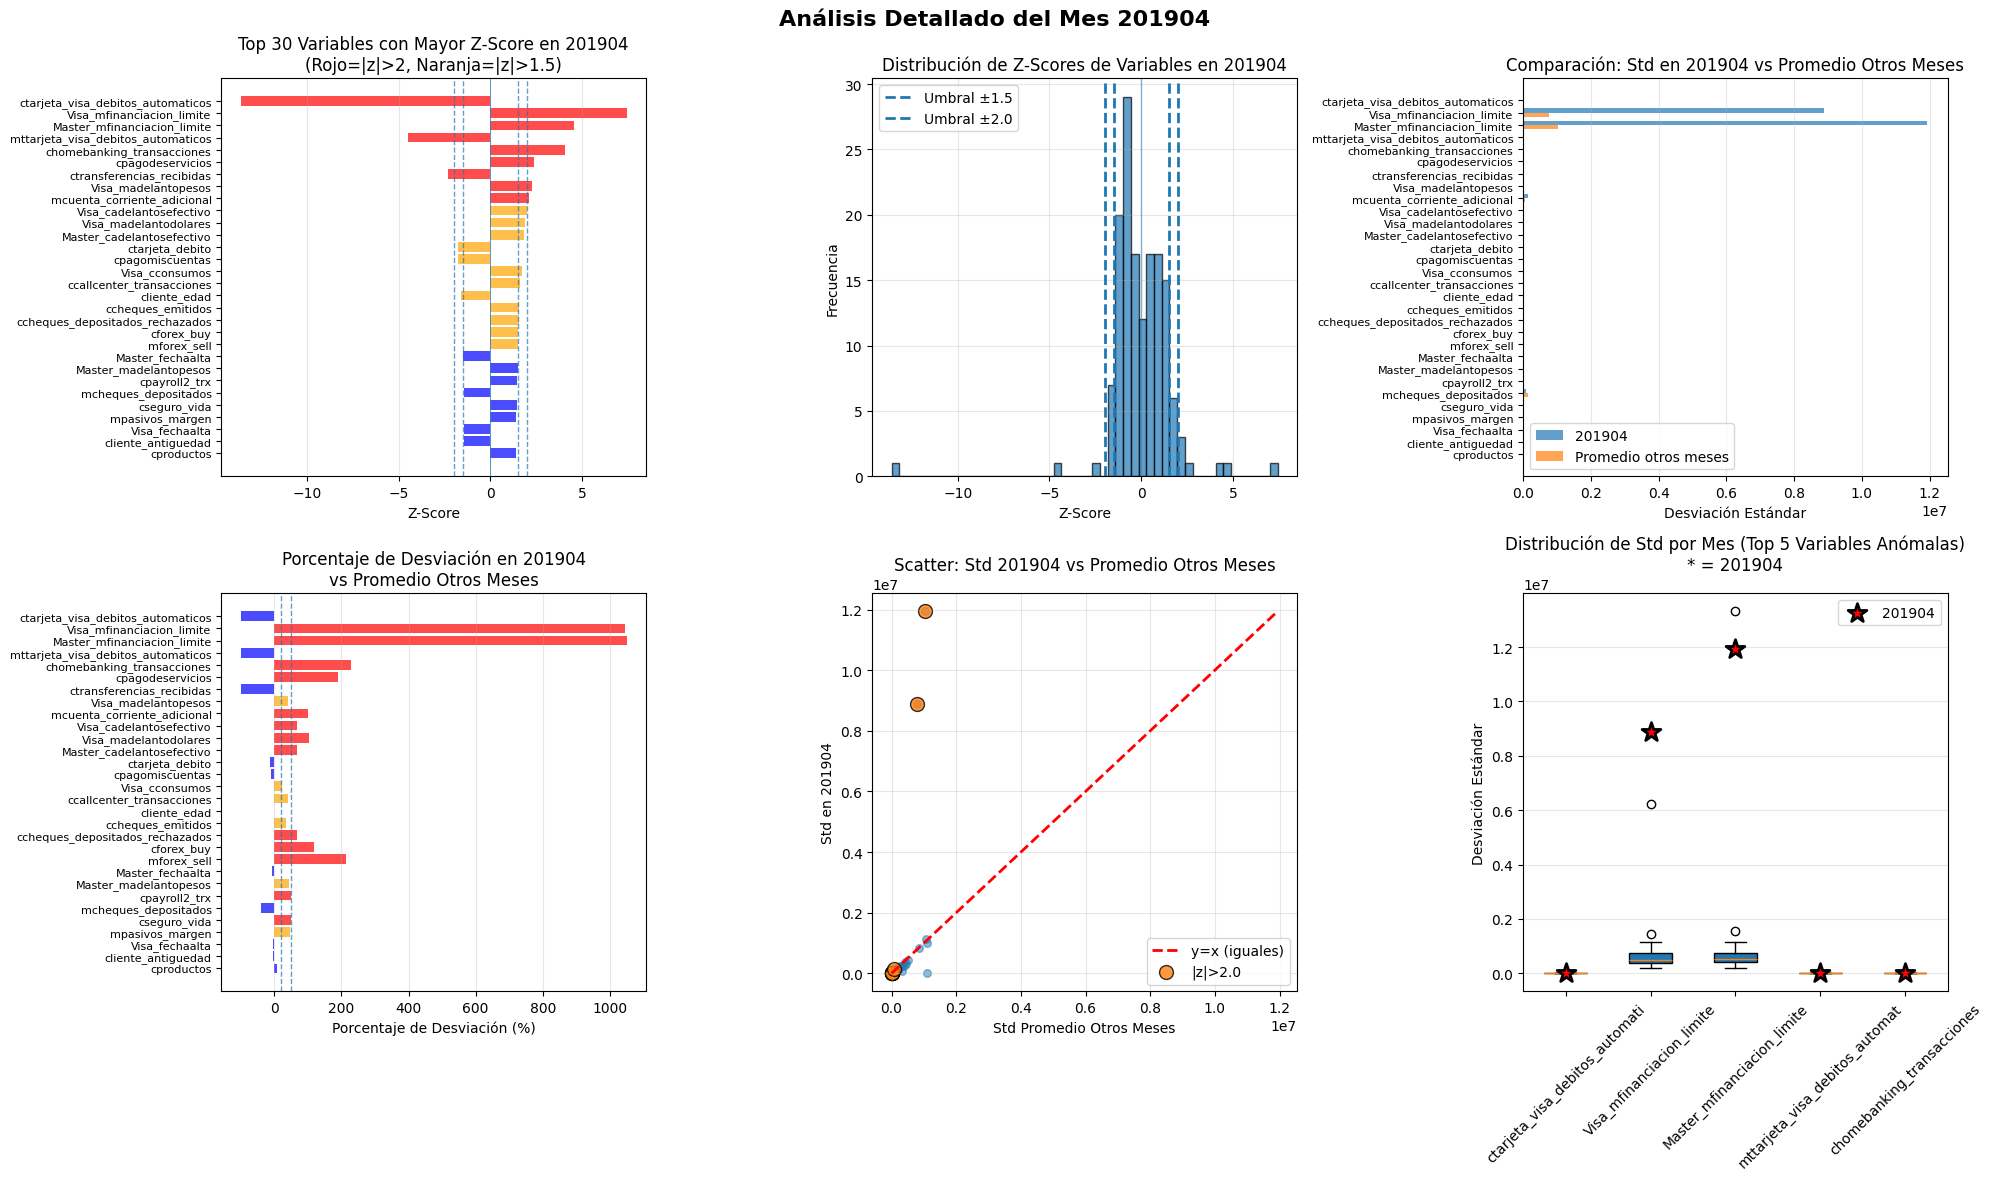


RESUMEN FINAL - MES 201904

✅ Total de variables analizadas: 152
⚠️  Variables con |z-score| > 2.0: 9 (5.9%)
📈 Variables con |z-score| > 1.5: 21 (13.8%)

💡 El mes 201904 tiene alta variabilidad principalmente en:
   - Visa: z-score promedio = 1.74

ANÁLISIS DEL MES 202006

📊 RESUMEN DEL MES 202006
   - Desviación estándar promedio: 53796.5699
   - Desviación estándar promedio de otros meses: 71519.2611
   - Diferencia: -17722.6912

TOP 20 VARIABLES CON MAYOR Z-SCORE (más anómalas en 202006)
                     variable  std_mes_202006  std_promedio_otros_meses  porcentaje_desviacion    z_score
                 thomebanking        0.000000              4.272455e-01            -100.000000 -32.595711
               active_quarter        0.000000              1.174449e-01            -100.000000 -15.985503
                     catm_trx        0.000000              3.733570e+00            -100.000000 -14.951153
     cextraccion_autoservicio        0.000000              4.451822e+00        

/tmp/ipykernel_7458/889053266.py:295: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax6.boxplot(


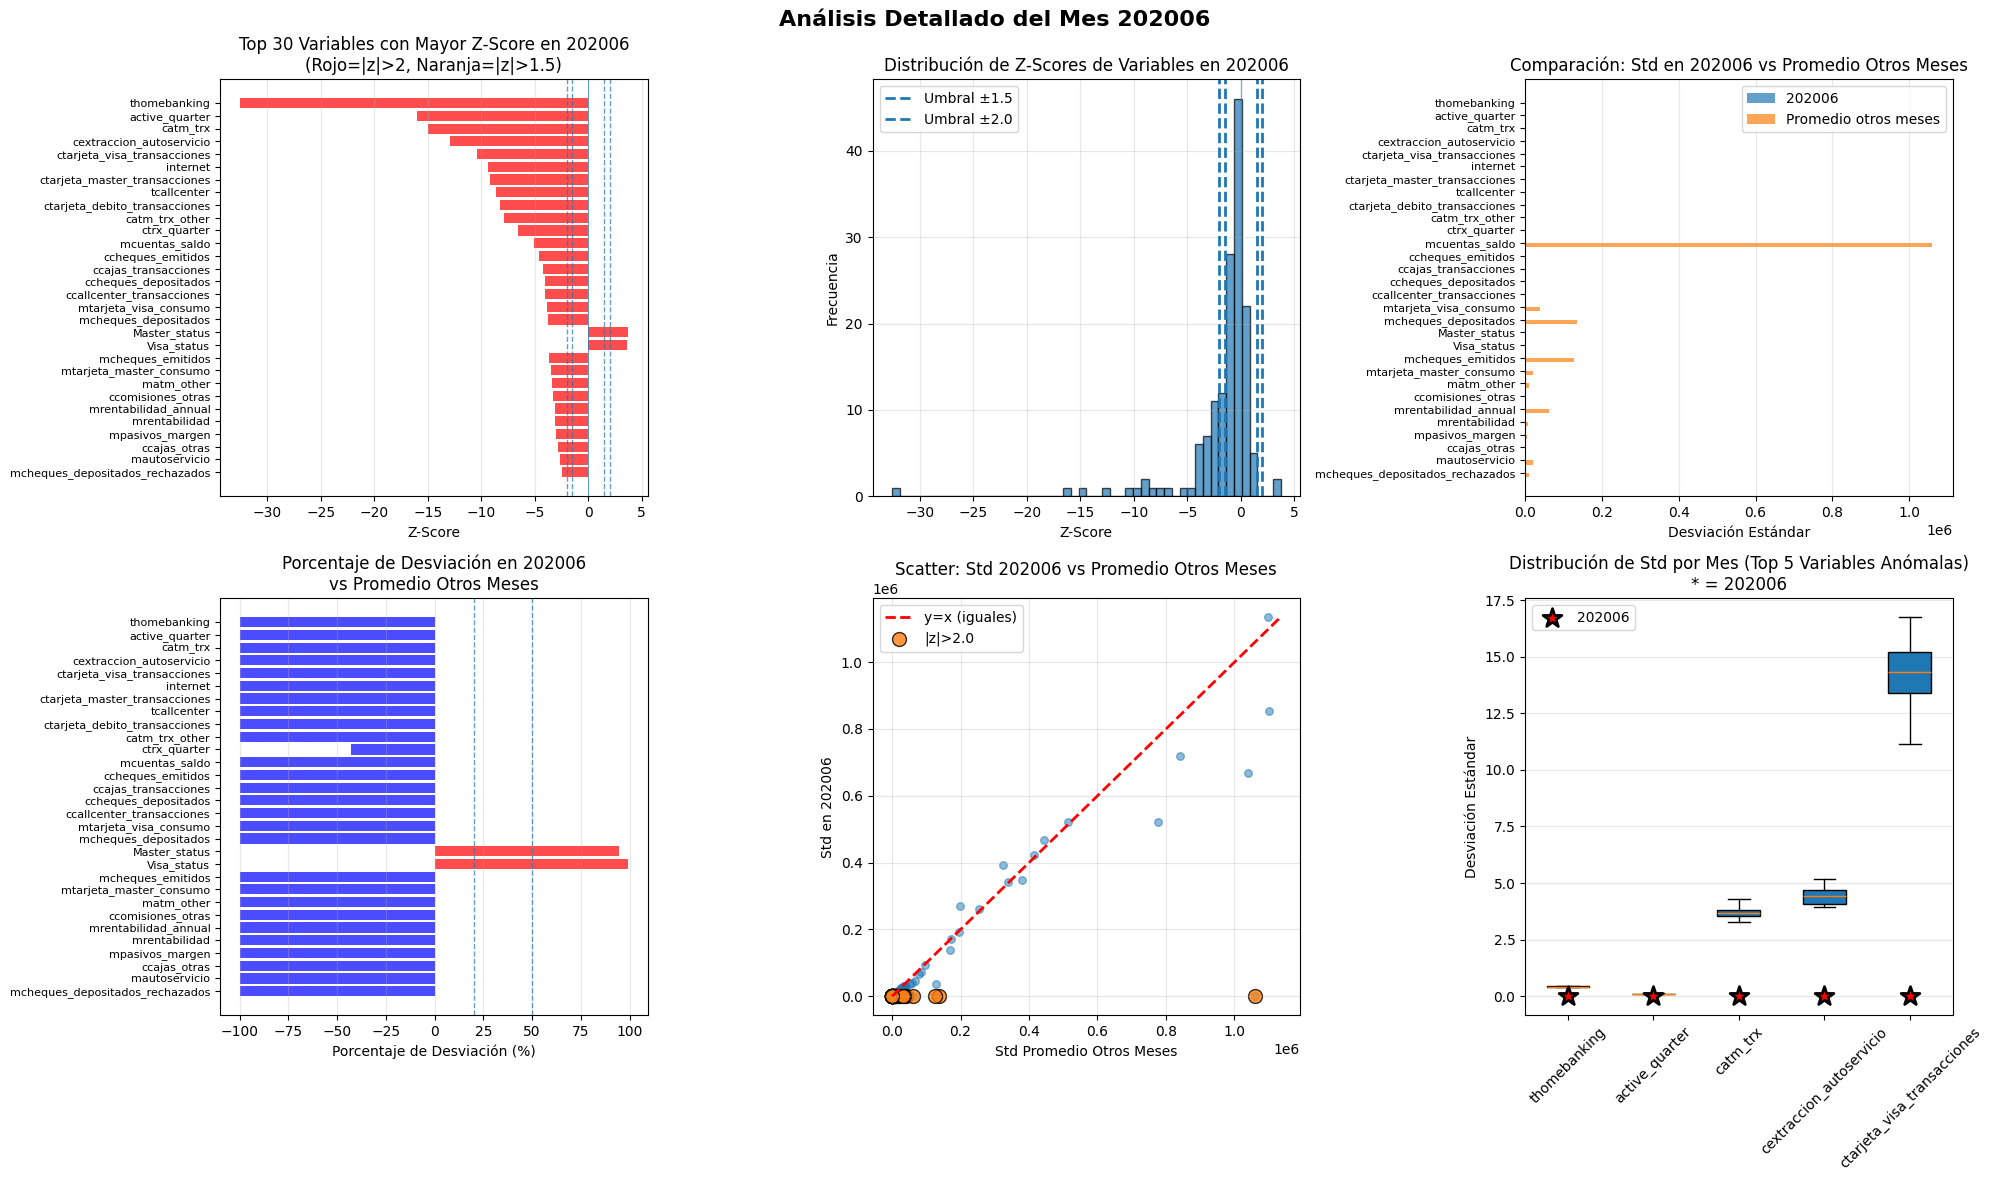


RESUMEN FINAL - MES 202006

✅ Total de variables analizadas: 152
⚠️  Variables con |z-score| > 2.0: 41 (27.0%)
📈 Variables con |z-score| > 1.5: 49 (32.2%)

💡 El mes 202006 tiene alta variabilidad principalmente en:
   - Contadores (c_): z-score promedio = 2.24

ANÁLISIS DEL MES 202010

📊 RESUMEN DEL MES 202010
   - Desviación estándar promedio: 67657.3482
   - Desviación estándar promedio de otros meses: 71519.2611
   - Diferencia: -3861.9129

TOP 20 VARIABLES CON MAYOR Z-SCORE (más anómalas en 202010)
                           variable  std_mes_202010  std_promedio_otros_meses  porcentaje_desviacion   z_score
    mcheques_depositados_rechazados    23430.467493               9937.742934             135.772525  3.385572
        mcuenta_debitos_automaticos   119804.432897              32798.750850             265.271328  2.703527
                 Master_Finiciomora        4.663078                 20.672459             -77.443042 -2.366288
                   Visa_Finiciomora        4.48

/tmp/ipykernel_7458/889053266.py:295: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax6.boxplot(


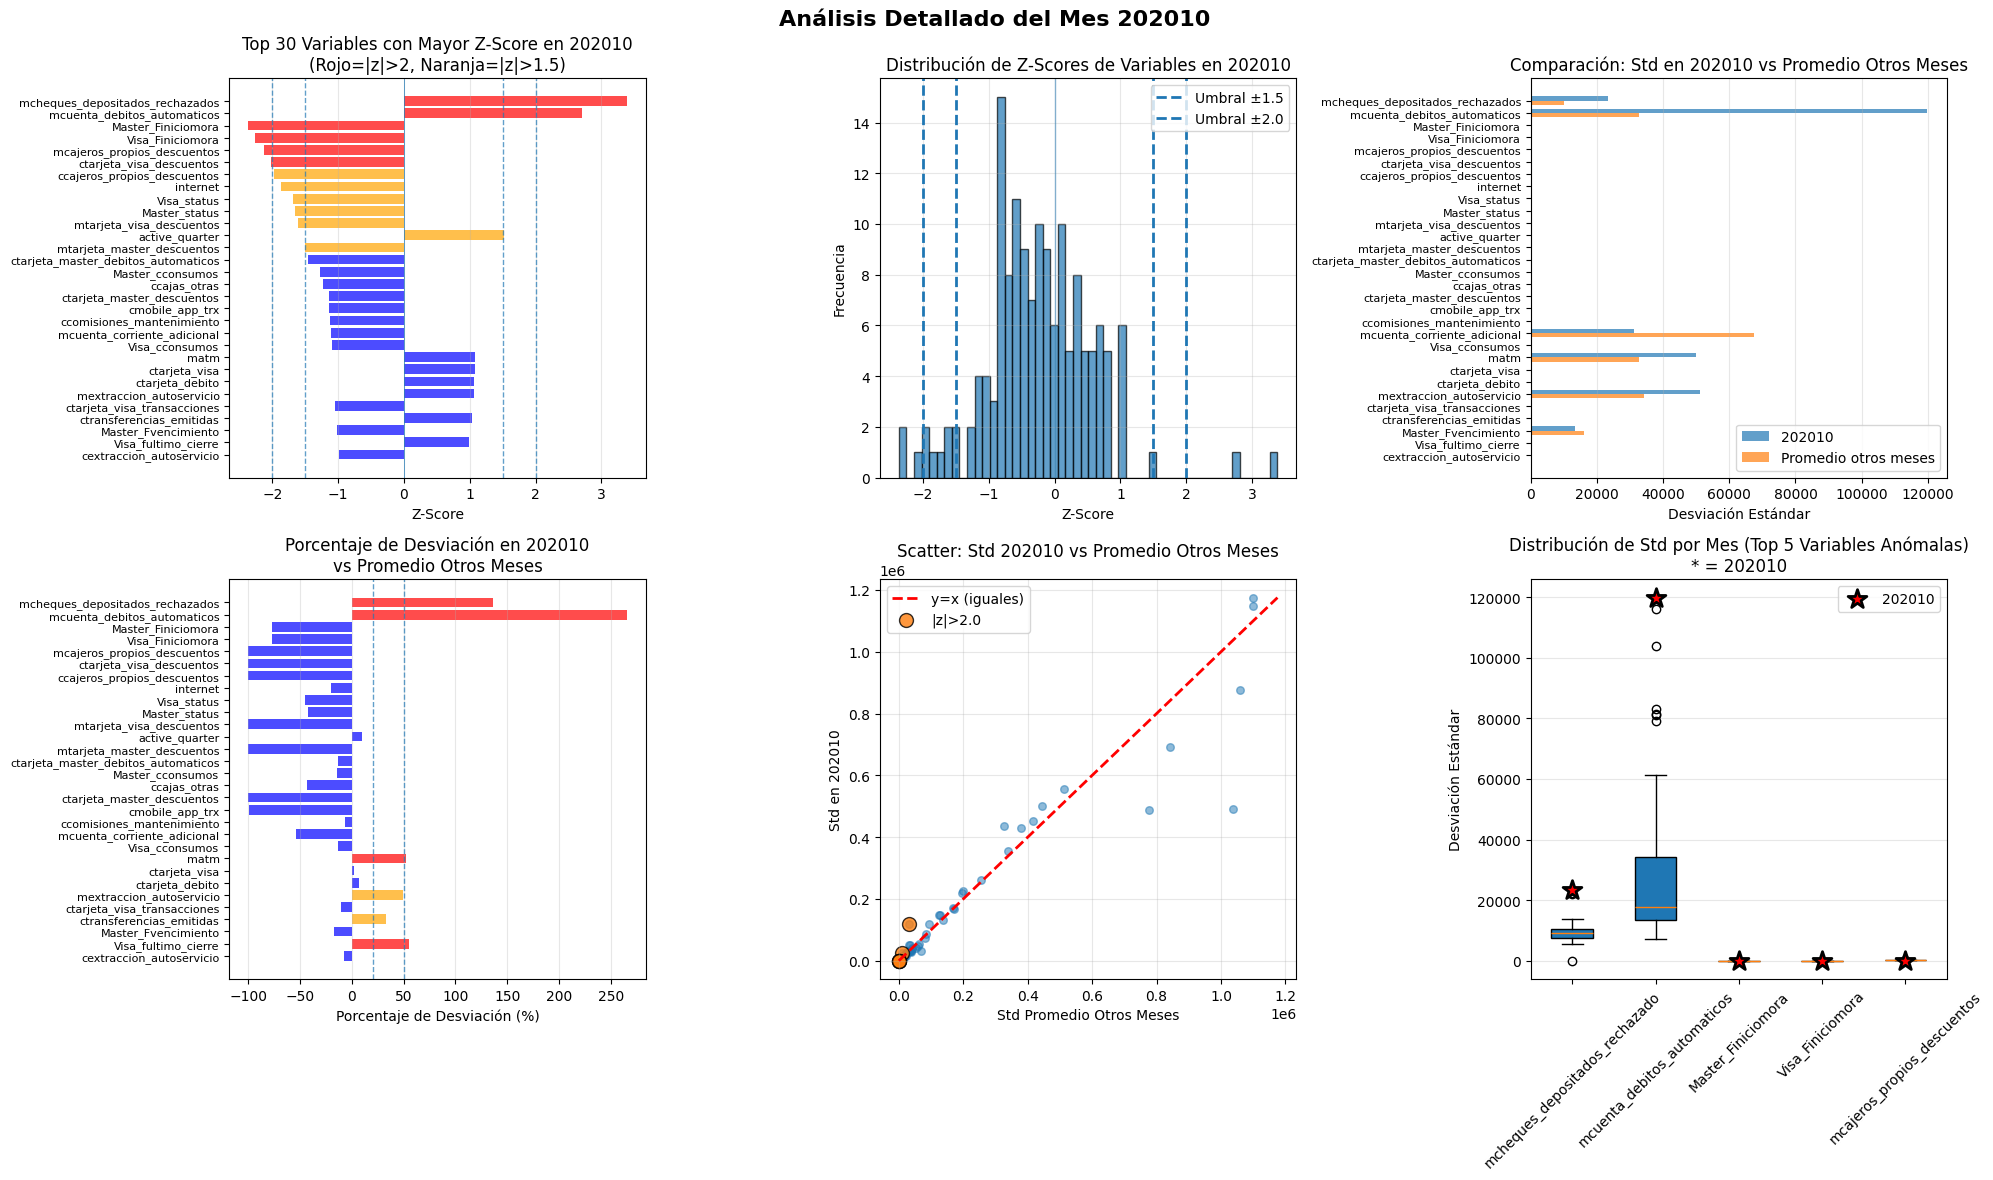


RESUMEN FINAL - MES 202010

✅ Total de variables analizadas: 152
⚠️  Variables con |z-score| > 2.0: 6 (3.9%)
📈 Variables con |z-score| > 1.5: 13 (8.6%)

💡 El mes 202010 tiene alta variabilidad principalmente en:

COMPARACIÓN ENTRE MESES ANÓMALOS

Comparación de métricas entre meses anómalos:
   mes  std_promedio  vars_z_gt_2  vars_z_gt_1_5  z_score_promedio  z_score_maximo
201904 183123.443327            9             21          1.094786       13.606344
202006  53796.569878           41             49          1.961477       32.595711
202010  67657.348190            6             13          0.668648        3.385572

VARIABLES COMUNES ANÓMALAS ENTRE MESES

⚠️  No hay variables anómalas comunes a todos los meses.

📊 Variables anómalas (|z|>1.5) en AL MENOS 2 meses: 14
Variables compartidas:
   - Master_status
   - Visa_status
   - active_quarter
   - ccajeros_propios_descuentos
   - ccallcenter_transacciones
   - ccheques_depositados_rechazados
   - ccheques_emitidos
   - chomebanking

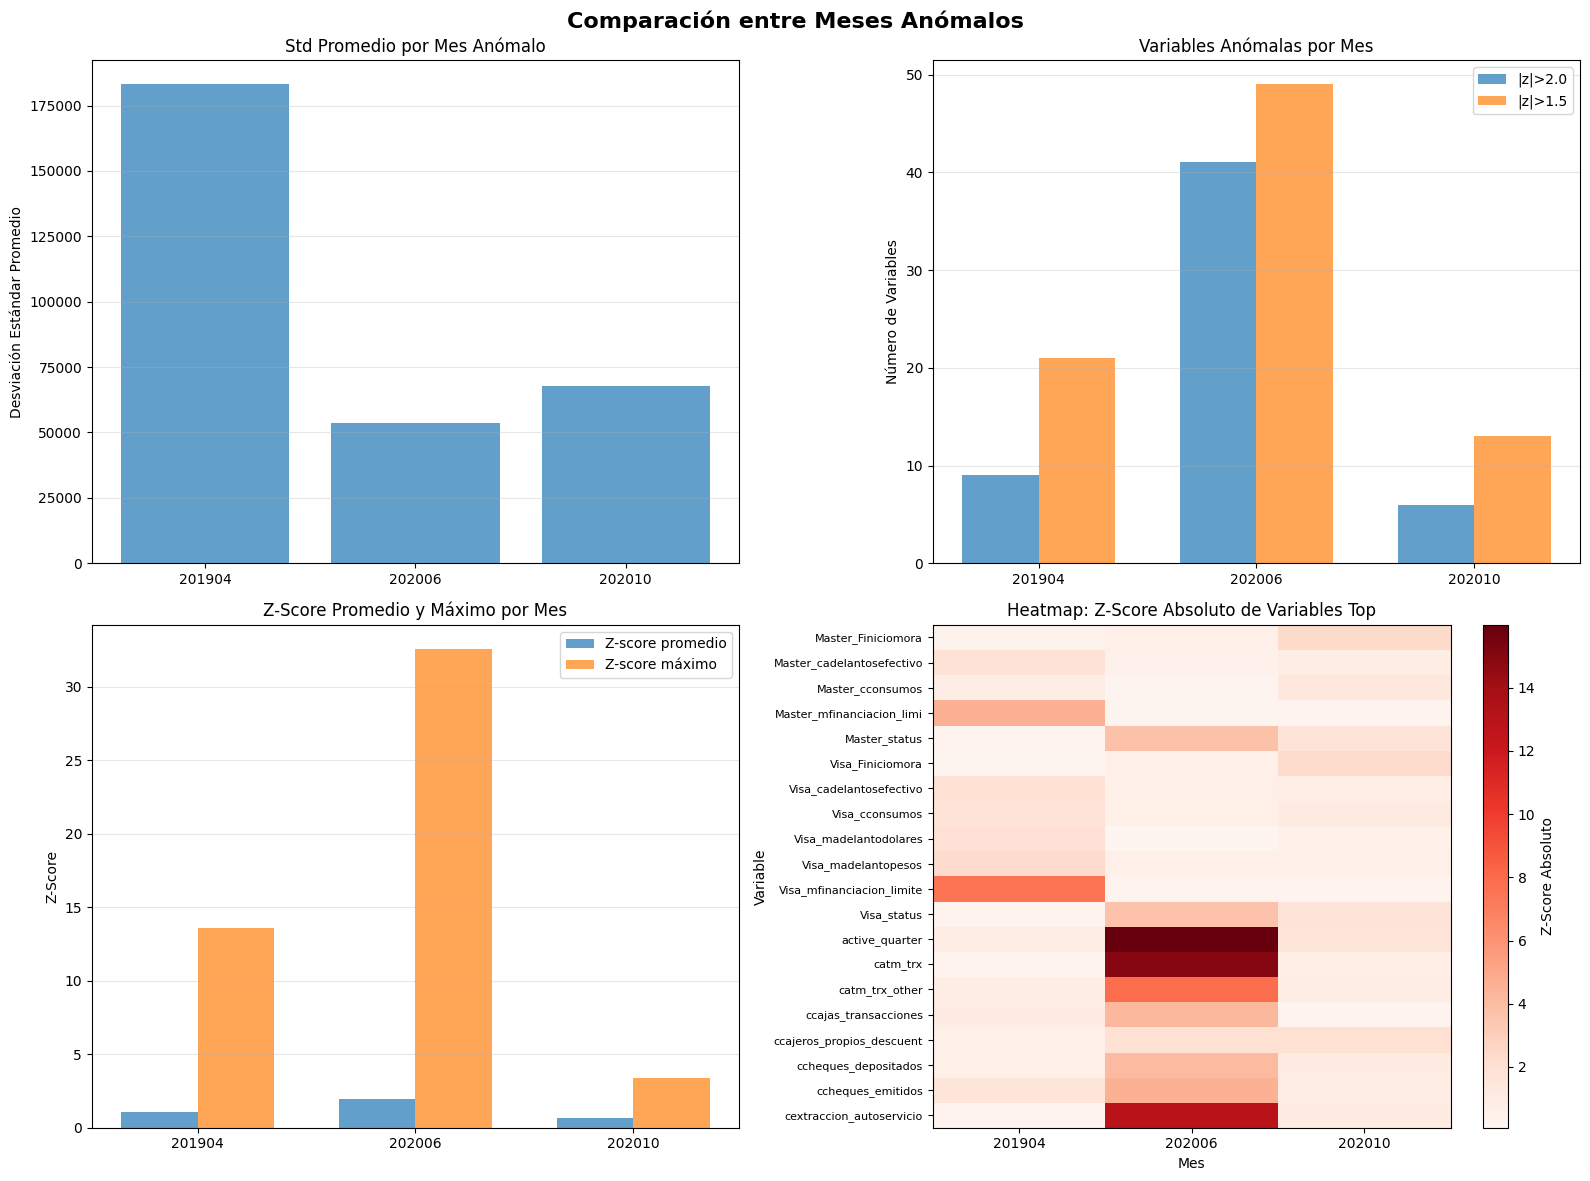

In [8]:
# =========================
# 3.1.1) Análisis detallado de meses anómalos - ¿Qué causa la alta variabilidad?
# =========================

meses_analizar = [201904, 202006, 202010]

print("=" * 80)
print(f"ANÁLISIS DETALLADO DE MESES: {meses_analizar}")
print("=" * 80)

# Excluir columnas no numéricas o de metadata
EXCLUDE_ANOMALY = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Obtener columnas numéricas (sin lags aún)
num_cols_base = [
    c for c, dt in zip(df.columns, df.dtypes)
    if c not in EXCLUDE_ANOMALY and dt.is_numeric()
]

# Calcular desviación estándar por mes para cada variable
std_por_mes_detalle = (
    df.lazy()
      .group_by("foto_mes")
      .agg([
          *[pl.col(c).std().alias(f"{c}_std") for c in num_cols_base]
      ])
      .sort("foto_mes")
      .collect()
)

# Convertir a pandas
std_df_detalle = std_por_mes_detalle.to_pandas()
meses_detalle = std_df_detalle["foto_mes"].values

# Verificar que todos los meses estén en el dataset
meses_validos = [m for m in meses_analizar if m in meses_detalle]
meses_no_validos = [m for m in meses_analizar if m not in meses_detalle]

if meses_no_validos:
    print(f"\n⚠️  Meses no encontrados en el dataset: {meses_no_validos}")

if not meses_validos:
    print(f"\n❌ Ninguno de los meses solicitados está en el dataset.")
else:
    # Almacenar resultados de todos los meses
    resultados_todos_meses = {}

    # Calcular stats globales excluyendo los meses anómalos (sirve para todos los meses)
    meses_normales = [m for m in meses_detalle if m not in meses_validos]
    std_df_normales = std_df_detalle[std_df_detalle["foto_mes"].isin(meses_normales)]

    std_media_por_variable = std_df_normales.drop(columns=["foto_mes"]).mean()
    std_std_por_variable = std_df_normales.drop(columns=["foto_mes"]).std()

    for mes_analizar in meses_validos:
        print("\n" + "=" * 80)
        print(f"ANÁLISIS DEL MES {mes_analizar}")
        print("=" * 80)

        # Filtrar datos del mes a analizar
        std_mes_analizar = std_df_detalle[std_df_detalle["foto_mes"] == mes_analizar].iloc[0]

        # Crear DataFrame con análisis detallado
        analisis_detalle = []
        for col in num_cols_base:
            col_std = f"{col}_std"

            std_val_mes = std_mes_analizar[col_std]
            std_media_global = std_media_por_variable[col_std]
            std_std_global = std_std_por_variable[col_std]

            if std_std_global > 0:
                z_score_var = (std_val_mes - std_media_global) / std_std_global
                desviacion_abs = std_val_mes - std_media_global
                porcentaje_desviacion = (desviacion_abs / (std_media_global + 1e-10)) * 100
            else:
                z_score_var = 0
                desviacion_abs = std_val_mes - std_media_global
                porcentaje_desviacion = 0

            analisis_detalle.append({
                "variable": col,
                f"std_mes_{mes_analizar}": std_val_mes,
                "std_promedio_otros_meses": std_media_global,
                "desviacion_absoluta": desviacion_abs,
                "porcentaje_desviacion": porcentaje_desviacion,
                "z_score": z_score_var
            })

        df_analisis = pd.DataFrame(analisis_detalle)

        # Ordenar por z-score absoluto (las más anómalas primero)
        df_analisis["z_score_abs"] = df_analisis["z_score"].abs()
        df_analisis = df_analisis.sort_values("z_score_abs", ascending=False)

        # Guardar resultados
        resultados_todos_meses[mes_analizar] = {
            "df_analisis": df_analisis,
            "std_mes_analizar": std_mes_analizar
        }

        col_std_mes = f"std_mes_{mes_analizar}"

        print(f"\n📊 RESUMEN DEL MES {mes_analizar}")
        print(f"   - Desviación estándar promedio: {df_analisis[col_std_mes].mean():.4f}")
        print(f"   - Desviación estándar promedio de otros meses: {df_analisis['std_promedio_otros_meses'].mean():.4f}")
        print(f"   - Diferencia: {df_analisis[col_std_mes].mean() - df_analisis['std_promedio_otros_meses'].mean():.4f}")

        # Top 20 variables más problemáticas
        print("\n" + "=" * 80)
        print(f"TOP 20 VARIABLES CON MAYOR Z-SCORE (más anómalas en {mes_analizar})")
        print("=" * 80)
        top_20 = df_analisis.head(20)
        print(
            top_20[[
                "variable", col_std_mes, "std_promedio_otros_meses",
                "porcentaje_desviacion", "z_score"
            ]].to_string(index=False)
        )

        # Variables con z-score > 2 (muy anómalas)
        vars_muy_anomalas = df_analisis[df_analisis["z_score_abs"] > 2.0]
        print(f"\n⚠️  Variables con |z-score| > 2.0: {len(vars_muy_anomalas)}")
        if len(vars_muy_anomalas) > 0:
            print("\nVariables muy anómalas:")
            for _, row in vars_muy_anomalas.head(10).iterrows():
                print(
                    f"   - {row['variable']}: z-score={row['z_score']:.2f}, "
                    f"desviación={row['porcentaje_desviacion']:.1f}%"
                )

        # Variables con z-score > 1.5 (anómalas)
        vars_anomalas = df_analisis[df_analisis["z_score_abs"] > 1.5]
        print(f"\n📈 Variables con |z-score| > 1.5: {len(vars_anomalas)}")

        # Estadísticas por categoría de variables
        print("\n" + "=" * 80)
        print("ANÁLISIS POR CATEGORÍAS DE VARIABLES")
        print("=" * 80)

        categorias = {
            "Montos (m_)": [c for c in num_cols_base if c.startswith("m_")],
            "Contadores (c_)": [c for c in num_cols_base if c.startswith("c") and not c.startswith("m_")],
            "Visa": [c for c in num_cols_base if "Visa" in c or "visa" in c],
            "Master": [c for c in num_cols_base if "Master" in c or "master" in c],
            "Payroll": [c for c in num_cols_base if "payroll" in c.lower()],
            "Prestamos": [c for c in num_cols_base if "prestamo" in c.lower()],
            "Inversiones": [c for c in num_cols_base if "inversion" in c.lower() or "plazo_fijo" in c.lower()],
        }

        for cat_name, vars_cat in categorias.items():
            if len(vars_cat) > 0:
                df_cat = df_analisis[df_analisis["variable"].isin(vars_cat)]
                if len(df_cat) > 0:
                    z_score_promedio = df_cat["z_score_abs"].mean()
                    vars_anomalas_cat = len(df_cat[df_cat["z_score_abs"] > 1.5])

                    print(f"\n{cat_name}:")
                    print(f"   - Variables en categoría: {len(df_cat)}")
                    print(f"   - Z-score promedio (abs): {z_score_promedio:.2f}")
                    print(f"   - Variables anómalas (|z|>1.5): {vars_anomalas_cat}")

                    if vars_anomalas_cat > 0:
                        top_cat = df_cat.nlargest(3, "z_score_abs")
                        print(f"   - Top 3 más anómalas:")
                        for _, row in top_cat.iterrows():
                            print(f"     * {row['variable']}: z={row['z_score']:.2f}")

        # Visualizaciones individuales por mes
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle(f"Análisis Detallado del Mes {mes_analizar}",
                     fontsize=16, fontweight='bold')

        # 1. Top 30 variables con mayor z-score
        ax1 = axes[0, 0]
        top_30 = df_analisis.head(30)
        colors = [
            'red' if abs(z) > 2 else 'orange' if abs(z) > 1.5 else 'blue'
            for z in top_30["z_score"]
        ]
        ax1.barh(range(len(top_30)), top_30["z_score"].values,
                 color=colors, alpha=0.7)
        ax1.set_yticks(range(len(top_30)))
        ax1.set_yticklabels(top_30["variable"].values, fontsize=8)
        ax1.set_xlabel("Z-Score")
        ax1.set_title(
            f"Top 30 Variables con Mayor Z-Score en {mes_analizar}\n"
            "(Rojo=|z|>2, Naranja=|z|>1.5)"
        )
        ax1.axvline(1.5, linestyle='--', linewidth=1, alpha=0.7)
        ax1.axvline(-1.5, linestyle='--', linewidth=1, alpha=0.7)
        ax1.axvline(2.0, linestyle='--', linewidth=1, alpha=0.7)
        ax1.axvline(-2.0, linestyle='--', linewidth=1, alpha=0.7)
        ax1.axvline(0, linestyle='-', linewidth=0.5)
        ax1.invert_yaxis()
        ax1.grid(axis='x', alpha=0.3)

        # 2. Distribución de z-scores
        ax2 = axes[0, 1]
        ax2.hist(df_analisis["z_score"], bins=50, edgecolor='black',
                 alpha=0.7)
        ax2.axvline(1.5, linestyle='--', linewidth=2, label='Umbral ±1.5')
        ax2.axvline(-1.5, linestyle='--', linewidth=2)
        ax2.axvline(2.0, linestyle='--', linewidth=2, label='Umbral ±2.0')
        ax2.axvline(-2.0, linestyle='--', linewidth=2)
        ax2.axvline(0, linestyle='-', linewidth=1, alpha=0.5)
        ax2.set_xlabel("Z-Score")
        ax2.set_ylabel("Frecuencia")
        ax2.set_title(f"Distribución de Z-Scores de Variables en {mes_analizar}")
        ax2.legend()
        ax2.grid(alpha=0.3)

        # 3. Comparación: std en mes_analizar vs promedio otros meses (top 30)
        ax3 = axes[0, 2]
        top_30_comp = df_analisis.head(30)
        x_pos = np.arange(len(top_30_comp))
        width = 0.35

        ax3.barh(
            x_pos - width / 2, top_30_comp[col_std_mes].values, width,
            label=f'{mes_analizar}', alpha=0.7
        )
        ax3.barh(
            x_pos + width / 2, top_30_comp["std_promedio_otros_meses"].values,
            width, label='Promedio otros meses', alpha=0.7
        )
        ax3.set_yticks(x_pos)
        ax3.set_yticklabels(top_30_comp["variable"].values, fontsize=8)
        ax3.set_xlabel("Desviación Estándar")
        ax3.set_title(f"Comparación: Std en {mes_analizar} vs Promedio Otros Meses")
        ax3.legend()
        ax3.invert_yaxis()
        ax3.grid(axis='x', alpha=0.3)

        # 4. Porcentaje de desviación (top 30)
        ax4 = axes[1, 0]
        top_30_pct = df_analisis.head(30)
        colors_pct = [
            'red' if p > 50 else 'orange' if p > 20 else 'blue'
            for p in top_30_pct["porcentaje_desviacion"]
        ]
        ax4.barh(
            range(len(top_30_pct)), top_30_pct["porcentaje_desviacion"].values,
            color=colors_pct, alpha=0.7
        )
        ax4.set_yticks(range(len(top_30_pct)))
        ax4.set_yticklabels(top_30_pct["variable"].values, fontsize=8)
        ax4.set_xlabel("Porcentaje de Desviación (%)")
        ax4.set_title(
            f"Porcentaje de Desviación en {mes_analizar}\nvs Promedio Otros Meses"
        )
        ax4.axvline(20, linestyle='--', linewidth=1, alpha=0.7)
        ax4.axvline(50, linestyle='--', linewidth=1, alpha=0.7)
        ax4.invert_yaxis()
        ax4.grid(axis='x', alpha=0.3)

        # 5. Scatter: std mes_analizar vs std promedio otros meses
        ax5 = axes[1, 1]
        ax5.scatter(
            df_analisis["std_promedio_otros_meses"],
            df_analisis[col_std_mes],
            alpha=0.5, s=30
        )
        max_val = max(
            df_analisis["std_promedio_otros_meses"].max(),
            df_analisis[col_std_mes].max()
        )
        ax5.plot([0, max_val], [0, max_val], 'r--', linewidth=2,
                 label='y=x (iguales)')
        vars_extremas = df_analisis[df_analisis["z_score_abs"] > 2.0]
        if len(vars_extremas) > 0:
            ax5.scatter(
                vars_extremas["std_promedio_otros_meses"],
                vars_extremas[col_std_mes],
                s=100, alpha=0.8, label='|z|>2.0',
                edgecolors='black'
            )
        ax5.set_xlabel("Std Promedio Otros Meses")
        ax5.set_ylabel(f"Std en {mes_analizar}")
        ax5.set_title(f"Scatter: Std {mes_analizar} vs Promedio Otros Meses")
        ax5.legend()
        ax5.grid(alpha=0.3)

        # 6. Boxplot de desviaciones estándar por mes (solo algunas variables clave)
        ax6 = axes[1, 2]
        top_5_vars = df_analisis.head(5)["variable"].tolist()

        data_boxplot, labels_boxplot = [], []
        for var in top_5_vars:
            col_std = f"{var}_std"
            valores = std_df_detalle[col_std].values
            data_boxplot.append(valores)
            labels_boxplot.append(var[:30])

        ax6.boxplot(
            data_boxplot, labels=labels_boxplot,
            vert=True, patch_artist=True
        )

        for i, var in enumerate(top_5_vars):
            col_std = f"{var}_std"
            std_val_mes = std_mes_analizar[col_std]
            ax6.scatter(
                [i + 1], [std_val_mes], s=200, c='red', marker='*',
                zorder=10, edgecolors='black', linewidth=2,
                label=f'{mes_analizar}' if i == 0 else ''
            )

        ax6.set_ylabel("Desviación Estándar")
        ax6.set_title(
            f"Distribución de Std por Mes (Top 5 Variables Anómalas)\n"
            f"* = {mes_analizar}"
        )
        ax6.tick_params(axis='x', rotation=45)
        ax6.grid(axis='y', alpha=0.3)
        ax6.legend()

        plt.tight_layout()
        plt.show()

        # Resumen final por mes
        print("\n" + "=" * 80)
        print(f"RESUMEN FINAL - MES {mes_analizar}")
        print("=" * 80)

        print(f"\n✅ Total de variables analizadas: {len(df_analisis)}")
        print(f"⚠️  Variables con |z-score| > 2.0: {len(vars_muy_anomalas)} "
              f"({len(vars_muy_anomalas)/len(df_analisis)*100:.1f}%)")
        print(f"📈 Variables con |z-score| > 1.5: {len(vars_anomalas)} "
              f"({len(vars_anomalas)/len(df_analisis)*100:.1f}%)")

        print(f"\n💡 El mes {mes_analizar} tiene alta variabilidad principalmente en:")
        if len(vars_muy_anomalas) > 0:
            top_categorias = []
            for cat_name, vars_cat in categorias.items():
                df_cat = df_analisis[df_analisis["variable"].isin(vars_cat)]
                if len(df_cat) > 0:
                    z_prom = df_cat["z_score_abs"].mean()
                    if z_prom > 1.5:
                        top_categorias.append((cat_name, z_prom))

            top_categorias.sort(key=lambda x: x[1], reverse=True)
            for cat, z_prom in top_categorias[:5]:
                print(f"   - {cat}: z-score promedio = {z_prom:.2f}")

    # Comparación entre meses anómalos
    if len(resultados_todos_meses) > 1:
        print("\n" + "=" * 80)
        print("COMPARACIÓN ENTRE MESES ANÓMALOS")
        print("=" * 80)

        comparacion_meses = []
        for mes, resultados in resultados_todos_meses.items():
            df_mes = resultados["df_analisis"]
            comparacion_meses.append({
                "mes": mes,
                "std_promedio": df_mes[f"std_mes_{mes}"].mean(),
                "vars_z_gt_2": len(df_mes[df_mes["z_score_abs"] > 2.0]),
                "vars_z_gt_1_5": len(df_mes[df_mes["z_score_abs"] > 1.5]),
                "z_score_promedio": df_mes["z_score_abs"].mean(),
                "z_score_maximo": df_mes["z_score_abs"].max()
            })

        df_comparacion = pd.DataFrame(comparacion_meses)
        print("\nComparación de métricas entre meses anómalos:")
        print(df_comparacion.to_string(index=False))

        print("\n" + "=" * 80)
        print("VARIABLES COMUNES ANÓMALAS ENTRE MESES")
        print("=" * 80)

        vars_por_mes = {}
        for mes, resultados in resultados_todos_meses.items():
            df_mes = resultados["df_analisis"]
            top_vars = df_mes[df_mes["z_score_abs"] > 1.5]["variable"].tolist()
            vars_por_mes[mes] = set(top_vars)

        if len(vars_por_mes) > 1:
            vars_comunes = set.intersection(*vars_por_mes.values())
            if vars_comunes:
                print(f"\n✅ Variables anómalas (|z|>1.5) en TODOS los meses analizados: {len(vars_comunes)}")
                print("Variables comunes:")
                for var in sorted(list(vars_comunes))[:20]:
                    print(f"   - {var}")
            else:
                print("\n⚠️  No hay variables anómalas comunes a todos los meses.")

            vars_en_al_menos_2 = set()
            for mes1, vars1 in vars_por_mes.items():
                for mes2, vars2 in vars_por_mes.items():
                    if mes1 != mes2:
                        vars_en_al_menos_2.update(vars1.intersection(vars2))

            if vars_en_al_menos_2:
                print(f"\n📊 Variables anómalas (|z|>1.5) en AL MENOS 2 meses: {len(vars_en_al_menos_2)}")
                print("Variables compartidas:")
                for var in sorted(list(vars_en_al_menos_2))[:30]:
                    print(f"   - {var}")

        # Visualización comparativa
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle("Comparación entre Meses Anómalos", fontsize=16, fontweight='bold')

        # 1. Comparación de std promedio
        ax1 = axes[0, 0]
        meses_comp = df_comparacion["mes"].tolist()
        stds_comp = df_comparacion["std_promedio"].tolist()
        ax1.bar(range(len(meses_comp)), stds_comp, alpha=0.7)
        ax1.set_xticks(range(len(meses_comp)))
        ax1.set_xticklabels(meses_comp)
        ax1.set_ylabel("Desviación Estándar Promedio")
        ax1.set_title("Std Promedio por Mes Anómalo")
        ax1.grid(axis='y', alpha=0.3)

        # 2. Número de variables anómalas
        ax2 = axes[0, 1]
        x = np.arange(len(meses_comp))
        width = 0.35
        ax2.bar(x - width/2, df_comparacion["vars_z_gt_2"].tolist(), width,
                label='|z|>2.0', alpha=0.7)
        ax2.bar(x + width/2, df_comparacion["vars_z_gt_1_5"].tolist(), width,
                label='|z|>1.5', alpha=0.7)
        ax2.set_xticks(x)
        ax2.set_xticklabels(meses_comp)
        ax2.set_ylabel("Número de Variables")
        ax2.set_title("Variables Anómalas por Mes")
        ax2.legend()
        ax2.grid(axis='y', alpha=0.3)

        # 3. Z-score promedio y máximo
        ax3 = axes[1, 0]
        ax3.bar(x - width/2, df_comparacion["z_score_promedio"].tolist(), width,
                label='Z-score promedio', alpha=0.7)
        ax3.bar(x + width/2, df_comparacion["z_score_maximo"].tolist(), width,
                label='Z-score máximo', alpha=0.7)
        ax3.set_xticks(x)
        ax3.set_xticklabels(meses_comp)
        ax3.set_ylabel("Z-Score")
        ax3.set_title("Z-Score Promedio y Máximo por Mes")
        ax3.legend()
        ax3.grid(axis='y', alpha=0.3)

        # 4. Heatmap de variables más anómalas compartidas
        ax4 = axes[1, 1]
        top_vars_all = set()
        for mes, resultados in resultados_todos_meses.items():
            df_mes = resultados["df_analisis"]
            top_vars_all.update(df_mes.head(15)["variable"].tolist())

        top_vars_all = sorted(list(top_vars_all))[:20]

        matriz_comparacion = []
        for var in top_vars_all:
            fila = []
            for mes in meses_comp:
                df_mes = resultados_todos_meses[mes]["df_analisis"]
                var_data = df_mes[df_mes["variable"] == var]
                fila.append(var_data["z_score_abs"].iloc[0] if len(var_data) > 0 else 0)
            matriz_comparacion.append(fila)

        if matriz_comparacion:
            im = ax4.imshow(matriz_comparacion, aspect='auto', cmap='Reds')
            ax4.set_xticks(range(len(meses_comp)))
            ax4.set_xticklabels(meses_comp)
            ax4.set_yticks(range(len(top_vars_all)))
            ax4.set_yticklabels([v[:25] for v in top_vars_all], fontsize=8)
            ax4.set_xlabel("Mes")
            ax4.set_ylabel("Variable")
            ax4.set_title("Heatmap: Z-Score Absoluto de Variables Top")
            plt.colorbar(im, ax=ax4, label='Z-Score Absoluto')

        plt.tight_layout()
        plt.show()

        print("\n" + "=" * 80)


In [9]:
# =========================
# Feature engineering: agregados de montos/contadores
# =========================

# Totales de saldos en pesos
SALDOS_PESOS = [
    "mcuenta_corriente",
    "mcaja_ahorro",
    "mcuenta_corriente_adicional",
    "mcaja_ahorro_adicional",
    "mcuentas_saldo",
]

# Consumo tarjetas pesos
CONSUMO_TARJETAS_PESOS = [
    "mtarjeta_visa_consumo",
    "mtarjeta_master_consumo",
]

# Consumo tarjetas dólares
CONSUMO_TARJETAS_DOLARES = [
    "Visa_mconsumosdolares",
    "Master_mconsumosdolares",
]

# Pagos recurrentes pesos
PAGOS_RECURRENTE_PESOS = [
    "mpagodeservicios",
    "mpagomiscuentas",
    "mcuenta_debitos_automaticos",
    "mttarjeta_visa_debitos_automaticos",
    "mttarjeta_master_debitos_automaticos",
]

# Sumas de productos de inversión y plazos fijos pesos
INVERSIONES_PESOS = [
    "mplazo_fijo_pesos",
    "minversion1_pesos",
    "minversion2",
]

# Sumas de productos de inversión y plazos fijos dólares
INVERSIONES_DOLARES = [
    "mplazo_fijo_dolares",
    "minversion1_dolares",
]

# Endeudamiento total pesos
ENDEUDAMIENTO_PESOS = [
    "mprestamos_prendarios",
    "mprestamos_hipotecarios",
    "Master_msaldopesos",
    "Visa_msaldopesos",
    "Master_madelantopesos",
    "Visa_madelantopesos",
]

# Endeudamiento total dólares
ENDEUDAMIENTO_DOLARES = [
    "Master_msaldodolares",
    "Visa_msaldodolares",
    "Master_madelantodolares",
    "Visa_madelantodolares",
]

# Ingresos payroll pesos
PAYROLL_PESOS = [
    "mpayroll",
    "mpayroll2",
]

# Límites de compra
LIMITES_COMPRA = [
    "Master_mlimitecompra",
    "Visa_mlimitecompra",
]

# Suma de seguros contratados
SEGUROS_COUNT = [
    "cseguro_vida",
    "cseguro_auto",
    "cseguro_vivienda",
    "cseguro_accidentes_personales",
]

# Totales de transacciones (conteo)
TRANSACCIONES_COUNT = [
    "ctarjeta_debito_transacciones",
    "ctarjeta_visa_transacciones",
    "ctarjeta_master_transacciones",
    "chomebanking_transacciones",
    "cmobile_app_trx",
    "ccallcenter_transacciones",
    "catm_trx",
    "catm_trx_other",
    "ccajas_transacciones",
]

def sum_columns_safe(df: pl.DataFrame, cols: list[str]) -> pl.Series:
    existentes = [c for c in cols if c in df.columns]
    if not existentes:
        return pl.lit(0)
    return pl.sum_horizontal([pl.col(c) for c in existentes])

fe_columns = {
    "m_saldo_total_pesos": SALDOS_PESOS,
    "m_consumo_tarjetas_pesos": CONSUMO_TARJETAS_PESOS,
    "m_consumo_tarjetas_dolares": CONSUMO_TARJETAS_DOLARES,
    "m_pagos_recurrentes_pesos": PAGOS_RECURRENTE_PESOS,
    "m_inversiones_pesos": INVERSIONES_PESOS,
    "m_inversiones_dolares": INVERSIONES_DOLARES,
    "m_endeudamiento_pesos": ENDEUDAMIENTO_PESOS,
    "m_endeudamiento_dolares": ENDEUDAMIENTO_DOLARES,
    "m_payroll_total": PAYROLL_PESOS,
    "m_limite_compra_total": LIMITES_COMPRA,
    "c_seguros_total": SEGUROS_COUNT,
    "c_transacciones_total": TRANSACCIONES_COUNT,
}

df = df.with_columns([
    sum_columns_safe(df, cols).alias(col_name)
    for col_name, cols in fe_columns.items()
])

df.shape

(4717958, 167)

In [10]:
# =========================
# 4) Feature Engineering Histórico - Lags y DeltaLags
# =========================

# Excluir IDs y metadata
EXCLUDE = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Identificar columnas numéricas
num_cols = [c for c, dt in zip(df.columns, df.dtypes)
            if c not in EXCLUDE and dt.is_numeric()]

def add_lags_and_deltas(df: pl.DataFrame, cols: list[str]) -> pl.DataFrame:
    """
    Agregar lags y deltas de orden 1 y 2 - Baseline del profesor
    """
    out = df.sort(["numero_de_cliente", "foto_mes"]).lazy()

    # Lags 1 y 2
    out = out.with_columns([
        pl.col(c).shift(1).over("numero_de_cliente").alias(f"{c}_lag1") for c in cols
    ] + [
        pl.col(c).shift(2).over("numero_de_cliente").alias(f"{c}_lag2") for c in cols
    ])

    # Delta 1: x_t - x_{t-1} ; Delta 2: x_t - x_{t-2}
    out = out.with_columns([
        (pl.col(c) - pl.col(f"{c}_lag1")).alias(f"{c}_d1") for c in cols
    ] + [
        (pl.col(c) - pl.col(f"{c}_lag2")).alias(f"{c}_d2") for c in cols
    ])

    return out.collect()

# Aplicar lags y deltas
df = add_lags_and_deltas(df, num_cols)

df.shape

(4717958, 823)

In [11]:
# =========================
# 4.0.6) Feature Engineering: Percentiles por Mes - TOP 25 VARIABLES MÁS IMPORTANTES
# =========================
# 
# Calcula percentiles solo para las 25 variables más importantes del modelo.
# Esto es más eficiente computacionalmente y se enfoca en las features que realmente
# aportan valor al modelo.

print("="*80)
print("FEATURE ENGINEERING: PERCENTILES POR MES - TOP 25 VARIABLES")
print("="*80)

# Lista de las 25 variables más importantes (según feature importance)
TOP_25_VARIABLES = [
    "ctrx_quarter",
    "mcaja_ahorro",
    "ctarjeta_visa_transacciones",
    "m_consumo_tarjetas_pesos",
    "m_saldo_total_pesos",
    "mtarjeta_visa_consumo",
    "cpayroll_trx",
    "c_transacciones_total",
    "Visa_status",
    "mcuentas_saldo",
    "m_payroll_total",
    "Visa_Finiciomora",
    "mprestamos_personales",
    "mpayroll",
    "cdescubierto_preacordado",
    "ctrx_quarter_d1",
    "ctrx_quarter_lag1",
    "mcaja_ahorro_lag1",
    "mcuenta_corriente",
    "Master_fechaalta",
    "Visa_Fvencimiento",
    "m_pagos_recurrentes_pesos",
    "Visa_mpagospesos",
    "cliente_edad",
    "Visa_msaldototal"
]

print(f"\n📊 Variables seleccionadas para calcular percentiles: {len(TOP_25_VARIABLES)}")

# Verificar que las variables existan en el dataset
vars_existentes = [v for v in TOP_25_VARIABLES if v in df.columns]
vars_no_existentes = [v for v in TOP_25_VARIABLES if v not in df.columns]

if vars_no_existentes:
    print(f"\n⚠️  ADVERTENCIA: {len(vars_no_existentes)} variables no encontradas en el dataset:")
    for v in vars_no_existentes:
        print(f"   - {v}")
    print(f"\n   Se calcularán percentiles solo para las {len(vars_existentes)} variables existentes.")

if not vars_existentes:
    print("\n❌ ERROR: Ninguna de las variables especificadas existe en el dataset.")
    print("   Verifica que los nombres de las variables sean correctos.")
else:
    print(f"\n✅ Variables válidas encontradas: {len(vars_existentes)}")
    
    # Percentiles a calcular (elegidos para capturar diferentes partes de la distribución)
    PERCENTILES = [5, 10, 25, 50, 75, 90, 95]
    print(f"Percentiles a calcular: {PERCENTILES}")
    
    # Función para calcular percentiles por mes de forma eficiente
    def add_percentiles_by_month(df: pl.DataFrame, cols: list[str], percentiles: list[int]) -> pl.DataFrame:
        """
        Calcula percentiles por mes para cada variable y agrega features de posición relativa.
        
        Para cada variable y cada mes, calcula los percentiles de la distribución.
        Luego, para cada cliente, calcula en qué percentil se encuentra su valor.
        """
        out = df.sort(["foto_mes", "numero_de_cliente"]).lazy()
        
        # Calcular percentiles por mes para cada variable
        # Esto se hace agrupando por foto_mes
        percentile_expressions = []
        
        for col in cols:
            for p in percentiles:
                # Calcular el percentil p de la columna por mes
                # Usamos quantile sobre el grupo de foto_mes
                percentile_col = f"{col}_p{p}_by_month"
                percentile_expressions.append(
                    pl.col(col).quantile(p / 100.0).over("foto_mes").alias(percentile_col)
                )
        
        # Agregar los percentiles calculados primero
        out = out.with_columns(percentile_expressions)
        
        # Ahora calcular la posición relativa de cada cliente (en qué percentil está)
        # Para cada variable, comparar su valor con los percentiles del mes
        position_expressions = []
        
        for col in cols:
            # Calcular en qué percentil se encuentra el valor del cliente
            # Usamos rank normalizado por mes (0-100, donde 0 es el mínimo y 100 el máximo)
            rank_col = f"{col}_percentile_rank"
            position_expressions.append(
                (pl.col(col).rank("dense").over("foto_mes") / 
                 pl.col(col).count().over("foto_mes") * 100).alias(rank_col)
            )
            
            # También calcular si está por encima/por debajo de percentiles clave
            # Nota: Los percentiles ya fueron calculados arriba, así que podemos usarlos
            for p in [25, 50, 75, 90]:
                if p in percentiles:  # Solo si calculamos ese percentil
                    percentile_col = f"{col}_p{p}_by_month"
                    above_col = f"{col}_above_p{p}"
                    position_expressions.append(
                        (pl.col(col) > pl.col(percentile_col)).cast(pl.Int8).alias(above_col)
                    )
        
        out = out.with_columns(position_expressions)
        
        return out.collect()
    
    # Calcular percentiles por mes para cada variable
    print("\nCalculando percentiles por mes para las variables seleccionadas...")
    df = add_percentiles_by_month(df, vars_existentes, PERCENTILES)
    
    print(f"\n✅ Percentiles calculados y agregados al dataset")
    print(f"   Shape del dataset después de agregar percentiles: {df.shape}")
    
    # Contar nuevas features agregadas
    new_percentile_features = [c for c in df.columns 
                              if ("_p" in c and "_by_month" in c) or 
                              "_percentile_rank" in c or 
                              "_above_p" in c]
    
    print(f"\n📊 Nuevas features de percentiles agregadas: {len(new_percentile_features)}")
    print(f"   - Percentiles calculados por mes: {len([c for c in new_percentile_features if '_by_month' in c])}")
    print(f"   - Ranks de percentil: {len([c for c in new_percentile_features if '_percentile_rank' in c])}")
    print(f"   - Indicadores above/below percentiles: {len([c for c in new_percentile_features if '_above_p' in c])}")
    
    # Mostrar algunas features de ejemplo
    print(f"\n📋 Ejemplos de nuevas features:")
    for feat in sorted(new_percentile_features)[:15]:
        print(f"   - {feat}")
    
    print("\n" + "="*80)
    print("NOTA: Las variables originales se mantienen intactas.")
    print("El modelo puede usar valores originales, percentiles, o ambos según sea más útil.")
    print("="*80)


FEATURE ENGINEERING: PERCENTILES POR MES - TOP 25 VARIABLES

📊 Variables seleccionadas para calcular percentiles: 25

✅ Variables válidas encontradas: 25
Percentiles a calcular: [5, 10, 25, 50, 75, 90, 95]

Calculando percentiles por mes para las variables seleccionadas...

✅ Percentiles calculados y agregados al dataset
   Shape del dataset después de agregar percentiles: (4717958, 1123)

📊 Nuevas features de percentiles agregadas: 300
   - Percentiles calculados por mes: 175
   - Ranks de percentil: 25
   - Indicadores above/below percentiles: 100

📋 Ejemplos de nuevas features:
   - Master_fechaalta_above_p25
   - Master_fechaalta_above_p50
   - Master_fechaalta_above_p75
   - Master_fechaalta_above_p90
   - Master_fechaalta_p10_by_month
   - Master_fechaalta_p25_by_month
   - Master_fechaalta_p50_by_month
   - Master_fechaalta_p5_by_month
   - Master_fechaalta_p75_by_month
   - Master_fechaalta_p90_by_month
   - Master_fechaalta_p95_by_month
   - Master_fechaalta_percentile_rank
  

In [12]:
# =========================
# 4.1) Creacion de Canaritos
# =========================

plocal = SimpleNamespace(
    qcanaritos=5,
    min_data_in_leaf=20,
    learning_rate=1.0,
    gradient_bound=0.1,
    APO=5,
    ksemillerio=1,
)

df = create_canaritos(df, plocal.qcanaritos)

In [13]:
# Configuración de la competencia
TRAIN_MESES = [
    201901, 201902, 201903, #201904, 
    201905, 201906, 201907, 201908, 
    201909, 201910, 201911, 201912, 
    202001, 202002, 202003, 202004, 202005, #202006, 
    202007, 202008, 202009, #202010, 
    202011, 202012, 202101, 202102
]

TEST_MES   = 202104
TEST_MES2   = 202106

# APPLY_MES = 202108


In [14]:
# =========================
# 5) Undersampling de todos los registros CONTINUA al 3%
# =========================

train_subset = df.filter(pl.col("foto_mes").is_in(TRAIN_MESES))

# Separar registros por clase
registros_continua = train_subset.filter(pl.col("clase_ternaria") == "CONTINUA")
registros_baja = train_subset.filter(pl.col("clase_ternaria").is_in(["BAJA+1", "BAJA+2"]))

# Hacer undersampling del 3% de todos los registros CONTINUA
fraccion_sample = 0.03
n_total_continua = registros_continua.height
n_sample = max(1, int(np.ceil(n_total_continua * fraccion_sample)))

registros_continua_sample = registros_continua.sample(n=n_sample, seed=SEEDS[0])

# Combinar registros CONTINUA muestreados con todos los BAJA
_df_train = pl.concat([registros_continua_sample, registros_baja])
_df_test = df.filter(pl.col("foto_mes") == TEST_MES)
# _df_apply = df.filter(pl.col("foto_mes") == APPLY_MES)

In [15]:
# =========================
# 5.1) Validación de la data
# =========================

print("_df_train shape:", _df_train.shape)
print("_df_test shape:", _df_test.shape)
#print("_df_apply shape:", _df_apply.shape)
print("Primeras columnas en df      :", df.columns[:10])
print("Primeras columnas en _df_train:", _df_train.columns[:10])

_df_train shape: (125208, 1128)
_df_test shape: (163418, 1128)
Primeras columnas en df      : ['canarito_1', 'canarito_2', 'canarito_3', 'canarito_4', 'canarito_5', 'numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet']
Primeras columnas en _df_train: ['canarito_1', 'canarito_2', 'canarito_3', 'canarito_4', 'canarito_5', 'numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet']


In [16]:
# =========================
# 6) Entrenamiento LightGBM con métrica de ganancia
# =========================

plocal = SimpleNamespace(
    qcanaritos=5,
    min_data_in_leaf=20,
    learning_rate=1.0,
    gradient_bound=0.1,
    APO=5,
    ksemillerio=1,
)

PARAM = SimpleNamespace(
    semilla_primigenia=SEEDS[0],
    qcanaritos=plocal.qcanaritos,
)

# Constantes de ganancia
GANANCIA_ACIERTO = 780000
COSTO_ESTIMULO = 20000

def calcular_ganancias_acumuladas(y_true, y_pred_proba):
    """Calcula la ganancia acumulada ordenando por probabilidad descendente."""
    df_eval = pl.DataFrame({"y_true": y_true, "y_pred_proba": y_pred_proba})
    df_ordenado = df_eval.sort("y_pred_proba", descending=True)
    df_ordenado = df_ordenado.with_columns(
        pl.when(pl.col("y_true") == 1)
        .then(GANANCIA_ACIERTO)
        .otherwise(-COSTO_ESTIMULO)
        .alias("ganancia_individual")
    )
    df_ordenado = df_ordenado.with_columns(
        pl.col("ganancia_individual").cast(pl.Int64).cum_sum().alias("ganancia_acumulada")
    )
    return df_ordenado["ganancia_acumulada"].to_numpy()


train_pd = _df_train.to_pandas()
test_pd = _df_test.to_pandas()
# apply_pd = _df_apply.to_pandas()

rng = np.random.default_rng(PARAM.semilla_primigenia)

drop_cols = {"numero_de_cliente", "foto_mes", "clase_ternaria"}
feature_cols = [c for c in train_pd.columns if c not in drop_cols]

print("=== Dataset shapes ===")
# print(f"train: {train_pd.shape} | test: {test_pd.shape} | apply: {apply_pd.shape}")
print(f"Features disponibles: {len(feature_cols)} (incluye canaritos={plocal.qcanaritos})")

y_train = train_pd["clase_ternaria"].isin(["BAJA+1", "BAJA+2"]).astype(int)
weight_train = np.where(y_train == 1, 1.00002, 1.0)

lgb_train = lgb.Dataset(train_pd[feature_cols], label=y_train, weight=weight_train)

lgbm_param_completo = {
    "boosting": "gbdt",
    "objective": "binary",
    "metric": "None",
    "first_metric_only": False,
    "boost_from_average": True,
    "feature_pre_filter": False,
    "force_row_wise": True,
    "verbosity": -100,
    "seed": PARAM.semilla_primigenia,
    "max_bin": 31,
    "min_data_in_leaf": plocal.min_data_in_leaf,
    "num_leaves": 9999,
    "learning_rate": plocal.learning_rate,
    "feature_fraction": 0.50,
    "canaritos": PARAM.qcanaritos,
    "gradient_bound": plocal.gradient_bound,
}

num_boost_round = 9999

print("\n=== Hyperparámetros principales ===")
print(
    f"seed={lgbm_param_completo['seed']} | min_leaf={plocal.min_data_in_leaf} | "
    f"learning_rate={plocal.learning_rate} | num_leaves={lgbm_param_completo['num_leaves']}"
)
print(
    f"canaritos={PARAM.qcanaritos} | gradient_bound={plocal.gradient_bound} | "
    f"feature_fraction={lgbm_param_completo['feature_fraction']} | rounds={num_boost_round}"
)

model = lgb.train(
    lgbm_param_completo,
    train_set=lgb_train,
    num_boost_round=num_boost_round,
)

best_iteration = model.best_iteration or num_boost_round
# apply_pd["pred_lgbm"] = model.predict(apply_pd[feature_cols], num_iteration=best_iteration)

valid_scores = model.predict(test_pd[feature_cols], num_iteration=best_iteration)


=== Dataset shapes ===
Features disponibles: 1125 (incluye canaritos=5)

=== Hyperparámetros principales ===
seed=509963 | min_leaf=20 | learning_rate=1.0 | num_leaves=9999
canaritos=5 | gradient_bound=0.1 | feature_fraction=0.5 | rounds=9999


In [17]:
# =========================
# 7) Ganancia real en TEST 202104
# =========================

test_pred_df = (
    pl.DataFrame(
        {
            "numero_de_cliente": test_pd["numero_de_cliente"],
            "foto_mes": test_pd["foto_mes"],
            "clase_ternaria": test_pd["clase_ternaria"],
            "probabilidad_baja": valid_scores,
        }
    )
    .with_columns(
        pl.col("clase_ternaria").eq("BAJA+2").cast(pl.Int64).alias("es_baja2")
    )
    .sort("probabilidad_baja", descending=True)
    .with_row_count("rank_envio", offset=1)
)

ganancias_acumuladas = calcular_ganancias_acumuladas(
    test_pred_df["es_baja2"].to_numpy(),
    test_pred_df["probabilidad_baja"].to_numpy(),
)

test_pred_df = test_pred_df.with_columns(
    pl.Series("ganancia_acumulada", ganancias_acumuladas)
)

ganancia_maxima = float(ganancias_acumuladas.max())
idx_mejor = int(np.argmax(ganancias_acumuladas))
n_envios_optimo = idx_mejor + 1

ganancia_envio_11000 = (
    int(ganancias_acumuladas[10999])
    if len(ganancias_acumuladas) >= 11000
    else None
)

print("=== Ganancia TEST 202104 ===")
print(f"Ganancia máxima: {ganancia_maxima:,.0f}")
print(f"Envíos óptimos: {n_envios_optimo} clientes")
if ganancia_envio_11000 is not None:
    print(f"Ganancia en 11.000 envíos: {ganancia_envio_11000:,.0f}")
else:
    print("Ganancia en 11.000 envíos: N/A (menos registros)")


=== Ganancia TEST 202104 ===
Ganancia máxima: 381,540,000
Envíos óptimos: 9403 clientes
Ganancia en 11.000 envíos: 374,400,000


/tmp/ipykernel_7458/3609290413.py:18: DeprecationWarning: `DataFrame.with_row_count` is deprecated. Use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  .with_row_count("rank_envio", offset=1)


In [18]:
# =========================
# 7.1) Ganancia real en TEST 202106
# =========================

TEST_MES2   = 202106
_df_test2 = df.filter(pl.col("foto_mes") == TEST_MES2)
test_pd2 = _df_test2.to_pandas()
valid_scores2 = model.predict(test_pd2[feature_cols], num_iteration=best_iteration)

test_pred_df2 = (
    pl.DataFrame(
        {
            "numero_de_cliente": test_pd2["numero_de_cliente"],
            "foto_mes": test_pd2["foto_mes"],
            "clase_ternaria": test_pd2["clase_ternaria"],
            "probabilidad_baja": valid_scores2,
        }
    )
    .with_columns(
        pl.col("clase_ternaria").eq("BAJA+2").cast(pl.Int64).alias("es_baja2")
    )
    .sort("probabilidad_baja", descending=True)
    .with_row_count("rank_envio", offset=1)
)

ganancias_acumuladas2 = calcular_ganancias_acumuladas(
    test_pred_df2["es_baja2"].to_numpy(),
    test_pred_df2["probabilidad_baja"].to_numpy(),
)

test_pred_df2 = test_pred_df2.with_columns(
    pl.Series("ganancia_acumulada", ganancias_acumuladas2)
)

ganancia_maxima2 = float(ganancias_acumuladas2.max())
idx_mejor2 = int(np.argmax(ganancias_acumuladas2))
n_envios_optimo2 = idx_mejor2 + 1

ganancia_envio_11000_2 = (
    int(ganancias_acumuladas2[10999])
    if len(ganancias_acumuladas2) >= 11000
    else None
)

print("=== Ganancia TEST 202106 ===")
print(f"Ganancia máxima: {ganancia_maxima2:,.0f}")
print(f"Envíos óptimos: {n_envios_optimo2} clientes")
if ganancia_envio_11000_2 is not None:
    print(f"Ganancia en 11.000 envíos: {ganancia_envio_11000_2:,.0f}")
else:
    print("Ganancia en 11.000 envíos: N/A (menos registros)")

=== Ganancia TEST 202106 ===
Ganancia máxima: 393,220,000
Envíos óptimos: 13139 clientes
Ganancia en 11.000 envíos: 388,800,000


/tmp/ipykernel_7458/2451744779.py:23: DeprecationWarning: `DataFrame.with_row_count` is deprecated. Use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  .with_row_count("rank_envio", offset=1)


/tmp/ipykernel_7458/628038026.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Top 10 features por gain
                                       feature           gain  split
110                               ctrx_quarter  332737.758492  16044
1000              ctrx_quarter_percentile_rank  128422.005377  18235
1005              mcaja_ahorro_percentile_rank   72401.876502  11566
158                   m_consumo_tarjetas_pesos   51665.782588   7663
1001                    ctrx_quarter_above_p25   50381.383339   1027
21                                mcaja_ahorro   43828.126219  13002
136                                Visa_status   30453.420414    508
1015  m_consumo_tarjetas_pesos_percentile_rank   21661.579273   7510
1016        m_consumo_tarjetas_pesos_above_p25   19766.556845    618
157                        m_saldo_total_pesos   19525.471949   9259


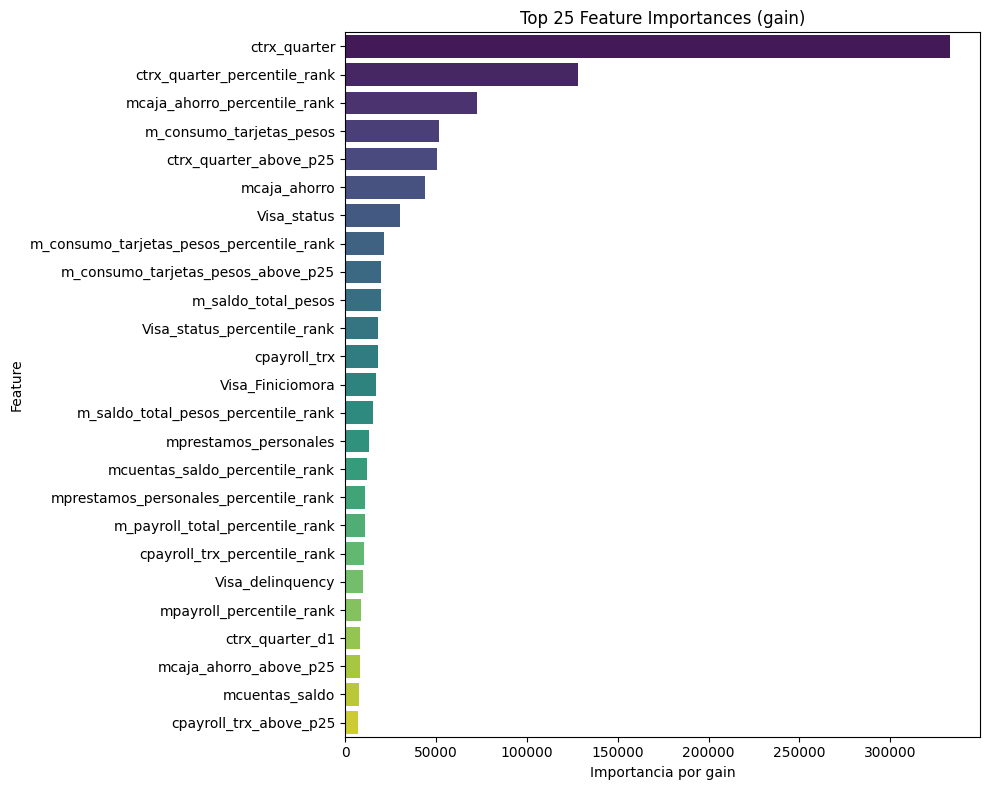

In [19]:
# =========================
# 8) Feature importance del modelo LightGBM
# =========================

feature_importance_gain = model.feature_importance(importance_type="gain")
feature_importance_split = model.feature_importance(importance_type="split")

importance_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "gain": feature_importance_gain,
            "split": feature_importance_split,
        }
    )
    .sort_values("gain", ascending=False)
)

print("Top 10 features por gain")
print(importance_df.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(25),
    x="gain",
    y="feature",
    palette="viridis",
)
plt.title("Top 25 Feature Importances (gain)")
plt.xlabel("Importancia por gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



In [22]:
# =========================
# 9) Predicciones binarias finales y archivo submit
# =========================

models = [model]
predictions_per_seed = [apply_pd["pred_lgbm"].to_numpy()]

predictions_matrix = np.vstack(predictions_per_seed)
final_predictions = np.mean(predictions_matrix, axis=0)

clientes_ordenados = np.argsort(final_predictions)[::-1]

n_clientes_objetivo = 11000
predicciones_binarias = np.zeros(len(final_predictions), dtype=int)
predicciones_binarias[clientes_ordenados[:n_clientes_objetivo]] = 1

id_apply = apply_pd["numero_de_cliente"].to_numpy()
submit_df = pd.DataFrame(
    {
        "numero_de_cliente": id_apply[clientes_ordenados],
        "Predicted": predicciones_binarias[clientes_ordenados],
    }
)

submit_df

submit_path = BASE_DIR / "202108_submit_lgbm.csv"
submit_path.parent.mkdir(parents=True, exist_ok=True)
submit_df.to_csv(submit_path, index=False)

print("=== Submit APPLY listo ===")
print(f"Archivo: {submit_path}")
print(f"Clientes positivos: {predicciones_binarias.sum()} de {len(predicciones_binarias)}")

#clientes_valid_ordenados = np.argsort(valid_scores)[::-1]
#predicciones_binarias_valid = np.zeros(len(valid_scores), dtype=int)
#predicciones_binarias_valid[clientes_valid_ordenados[:n_clientes_objetivo]] = 1

#id_valid = test_pd["numero_de_cliente"].to_numpy()
#submit_valid_df = pl.DataFrame(
#    {
#        "numero_de_cliente": id_valid[clientes_valid_ordenados],
#        "Predicted": predicciones_binarias_valid[clientes_valid_ordenados],
#    }
#)

#submit_valid_path = BASE_DIR / "submit_lgbm_test202106.csv"
#submit_valid_df.write_csv(submit_valid_path)

#print("\n=== Submit TEST 202106 listo ===")
#print(f"Archivo: {submit_valid_path}")
#print(f"Clientes positivos: {predicciones_binarias_valid.sum()} de {len(predicciones_binarias_valid)}")

=== Submit APPLY listo ===
Archivo: /home/nicocaviglia031/dmeyf2025/Competencia 2/dmeyf2025/202108_submit_lgbm.csv
Clientes positivos: 11000 de 164822


In [24]:
# Filtrar los clientes con Predicted == 1
df_filtered_ensemble = submit_df[submit_df["Predicted"] == 1][["numero_de_cliente"]]
# Guardar CSV sin encabezados ni índice
df_filtered_ensemble.to_csv("Charizard777.csv", index=False, header=False)

(11000, 1)
